# 绘制INP浓度的时间序列



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [3]:
data = pd.read_csv(r"D:\Coding\Data\Lanzhou_cfdc\test\data_20250120T082513.csv")

In [4]:
data = data.dropna(subset=['Lamina Average T [C]'])

In [36]:
data[0:2]

,Time,Air Pump,Vacuum Pump,T1,T2,T3,T4,T5,T6,T7,...,Bins (High Gain) 90,Bins (High Gain) 91,Bins (High Gain) 92,Bins (High Gain) 93,Bins (High Gain) 94,Bins (High Gain) 95,Bins (High Gain) 96,Bins (High Gain) 97,Bins (High Gain) 98,Bins (High Gain) 99
11956,42272.299682,True,False,-29.904047,-30.031778,-30.305759,-30.955812,-29.051908,-29.924276,NaN,...,0,1,1,0,0,0,0,0,0,0
11957,42273.299976,True,False,-29.870844,-29.965355,-30.405497,-30.939161,-29.068466,-29.990686,NaN,...,0,0,0,0,0,0,0,0,0,0


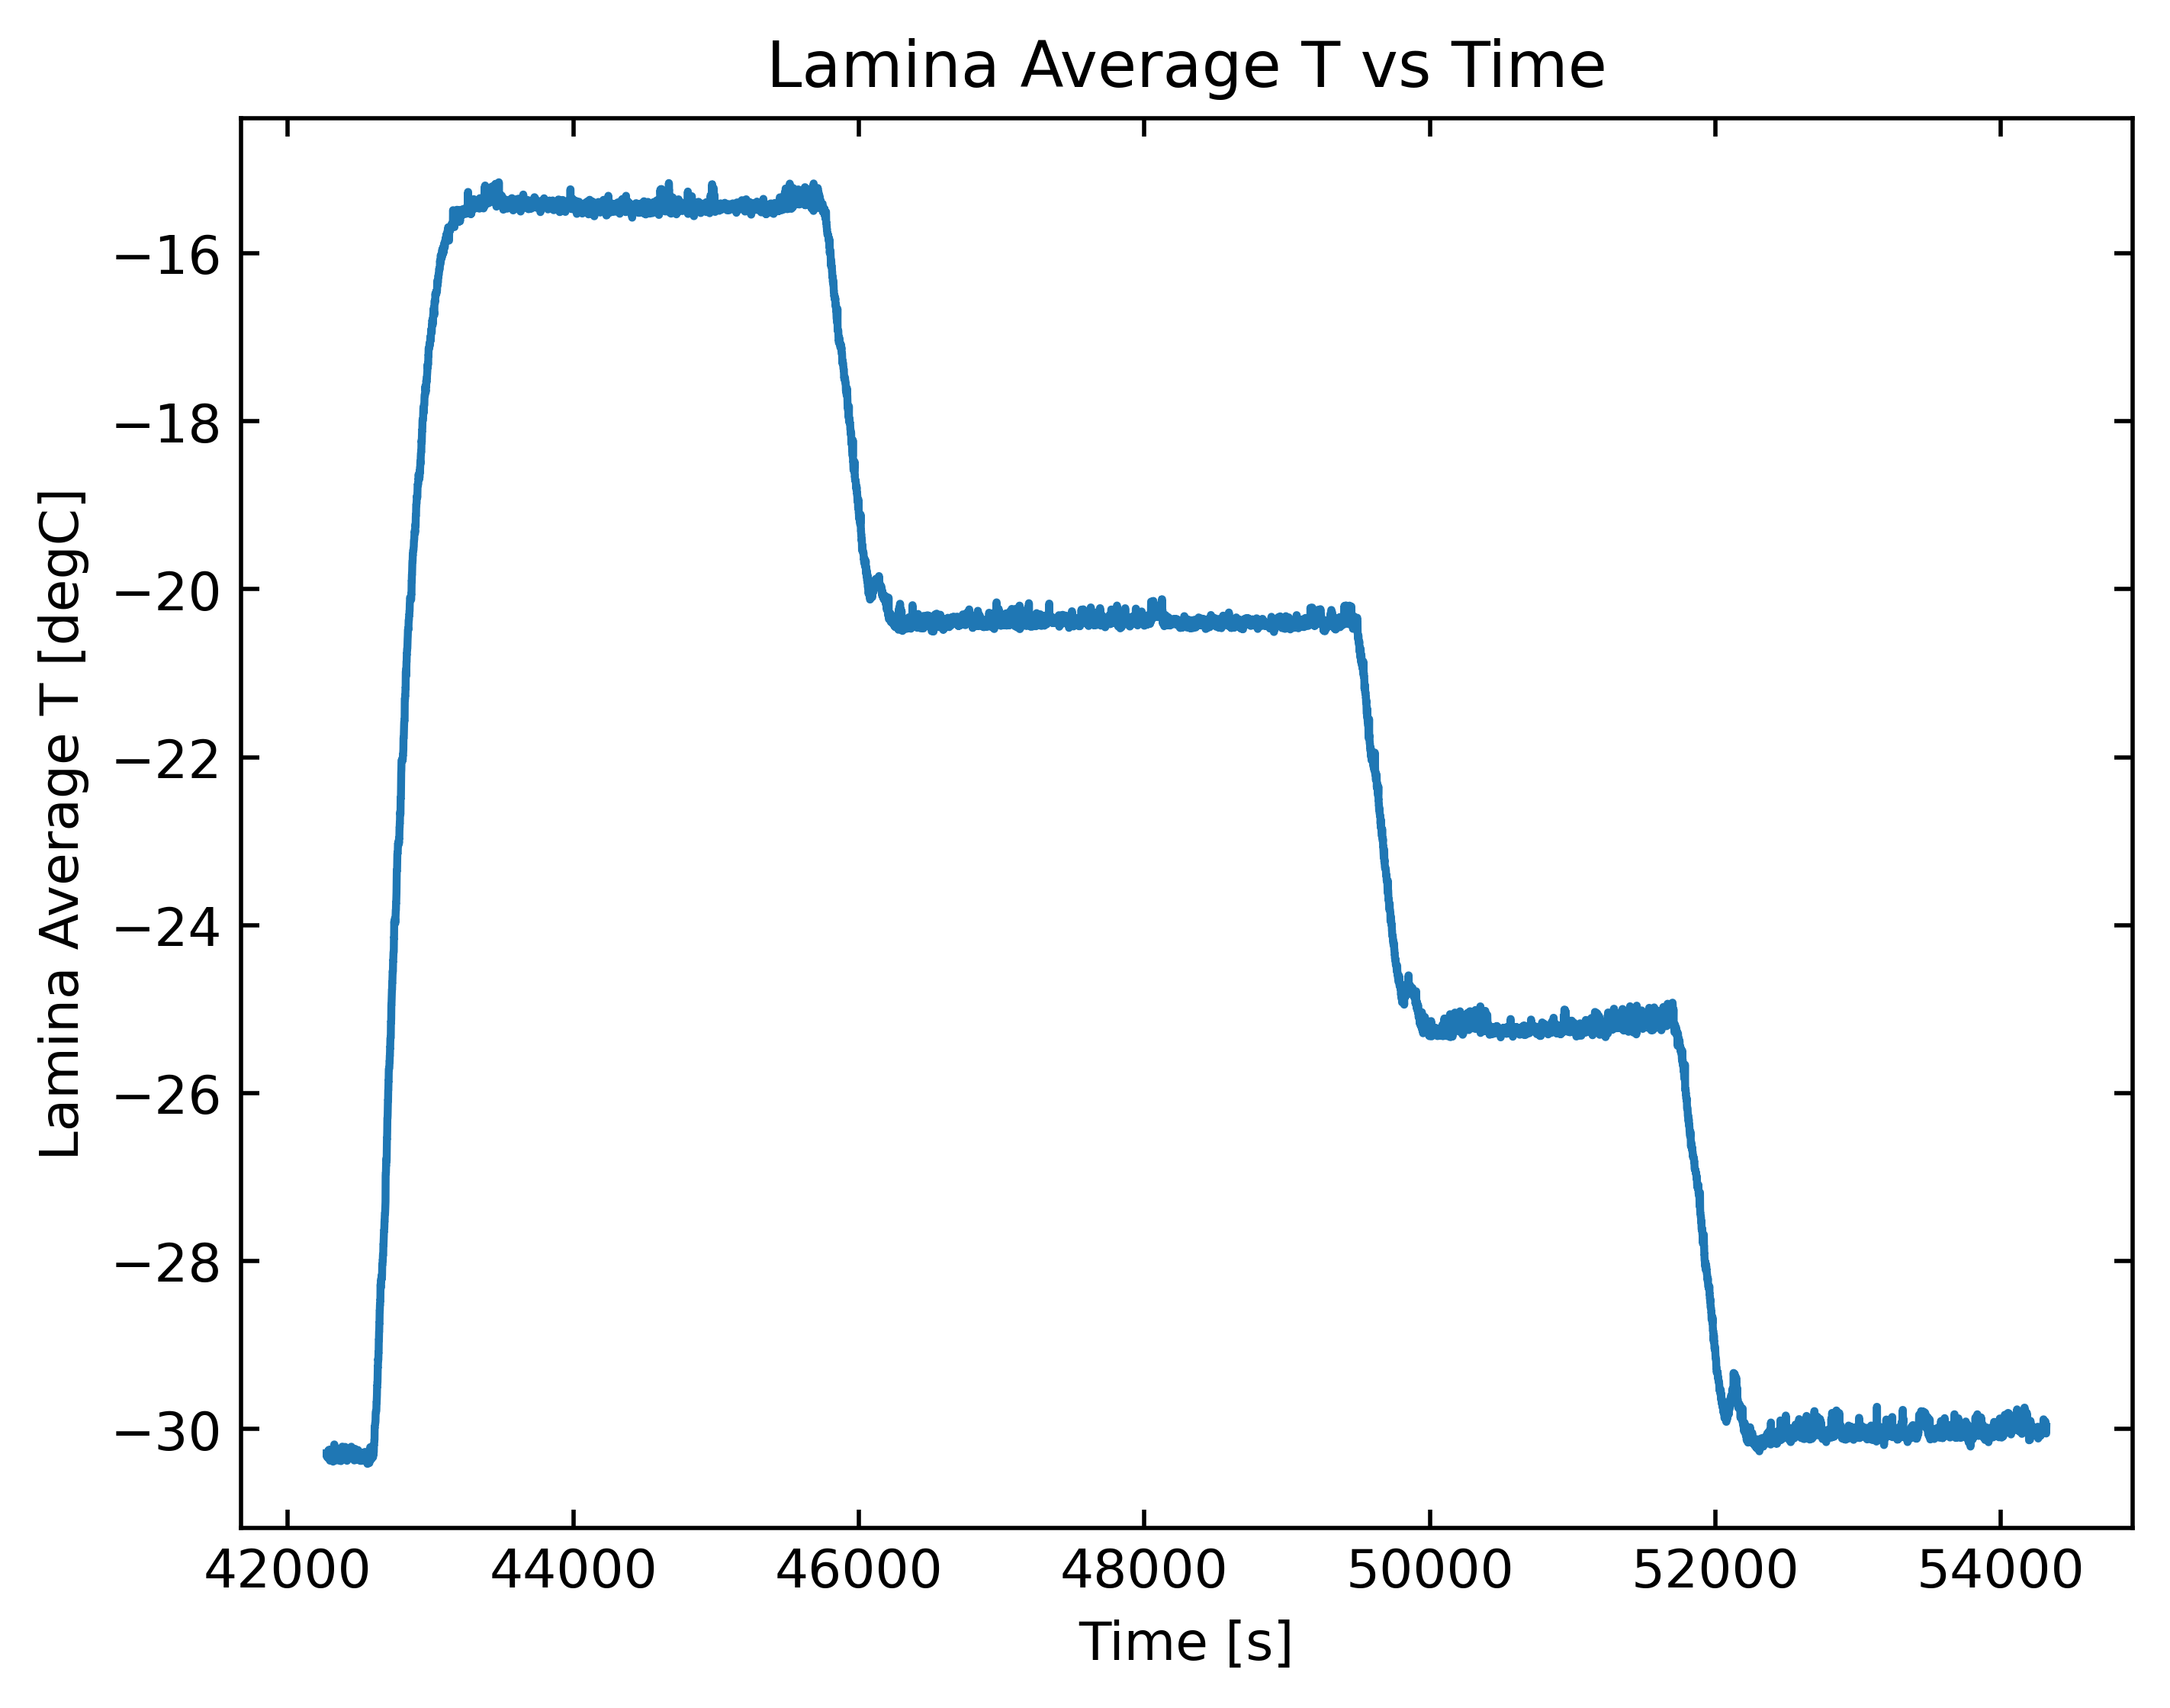

In [37]:
# Lamina Average T vs Time

x = data['Time']
y = data['Lamina Average T [C]']

fig = plt.figure(dpi=500)
ax = fig.add_subplot(111)

ax.plot(x, y)

ax.set_xlabel('Time [s]')
ax.set_ylabel('Lamina Average T [degC]')
ax.tick_params(which='both', top=True, bottom=True, left=True, right=True, direction='in')
ax.set_title('Lamina Average T vs Time')

plt.savefig(r"D:\Coding\master0_2025\Lanzhou_cfdc\Lamina_Average_T_vs_Time.png", bbox_inches='tight')

Text(0.5, 1.0, 'INP Counts vs Time')

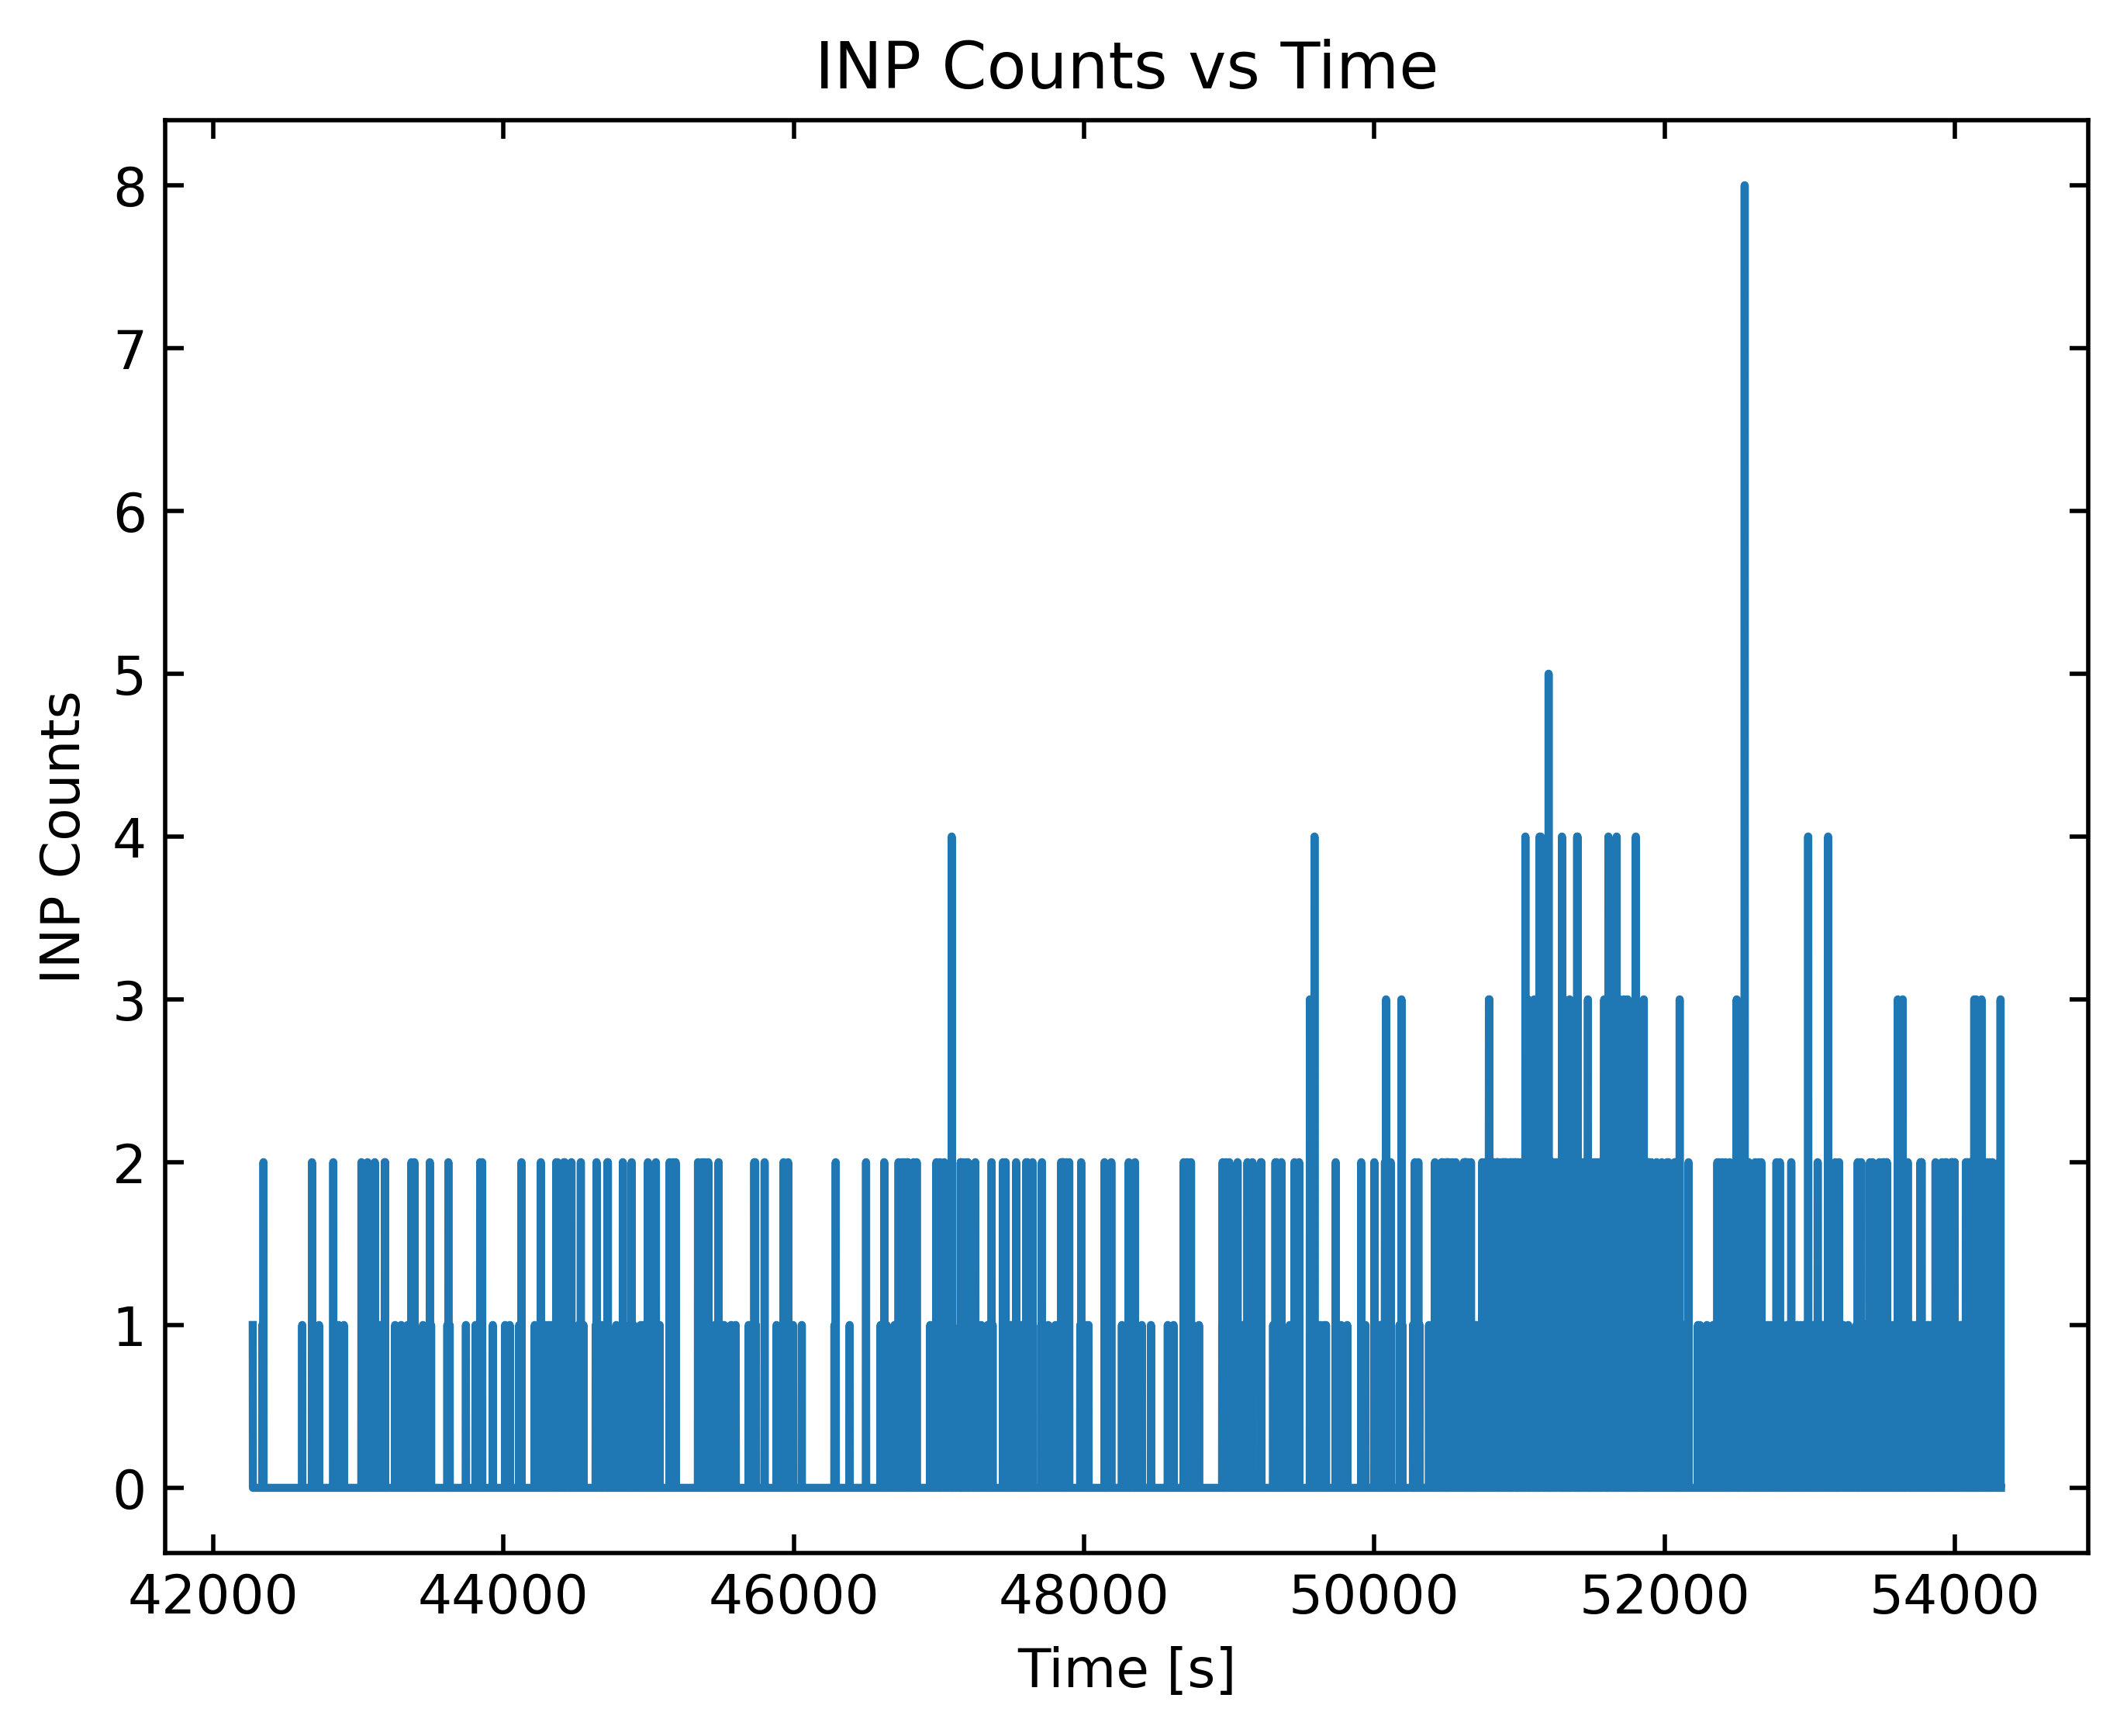

In [38]:
# INP Counts vs Time

x = data['Time']
y = data['INP Counts']

fig = plt.figure(dpi=500)
ax = fig.add_subplot(111)

ax.plot(x, y)

ax.set_xlabel('Time [s]')
ax.set_ylabel('INP Counts')
ax.tick_params(which='both', top=True, bottom=True, left=True, right=True, direction='in')
ax.set_title('INP Counts vs Time')

Text(0.5, 1.0, 'INP Conc vs Time')

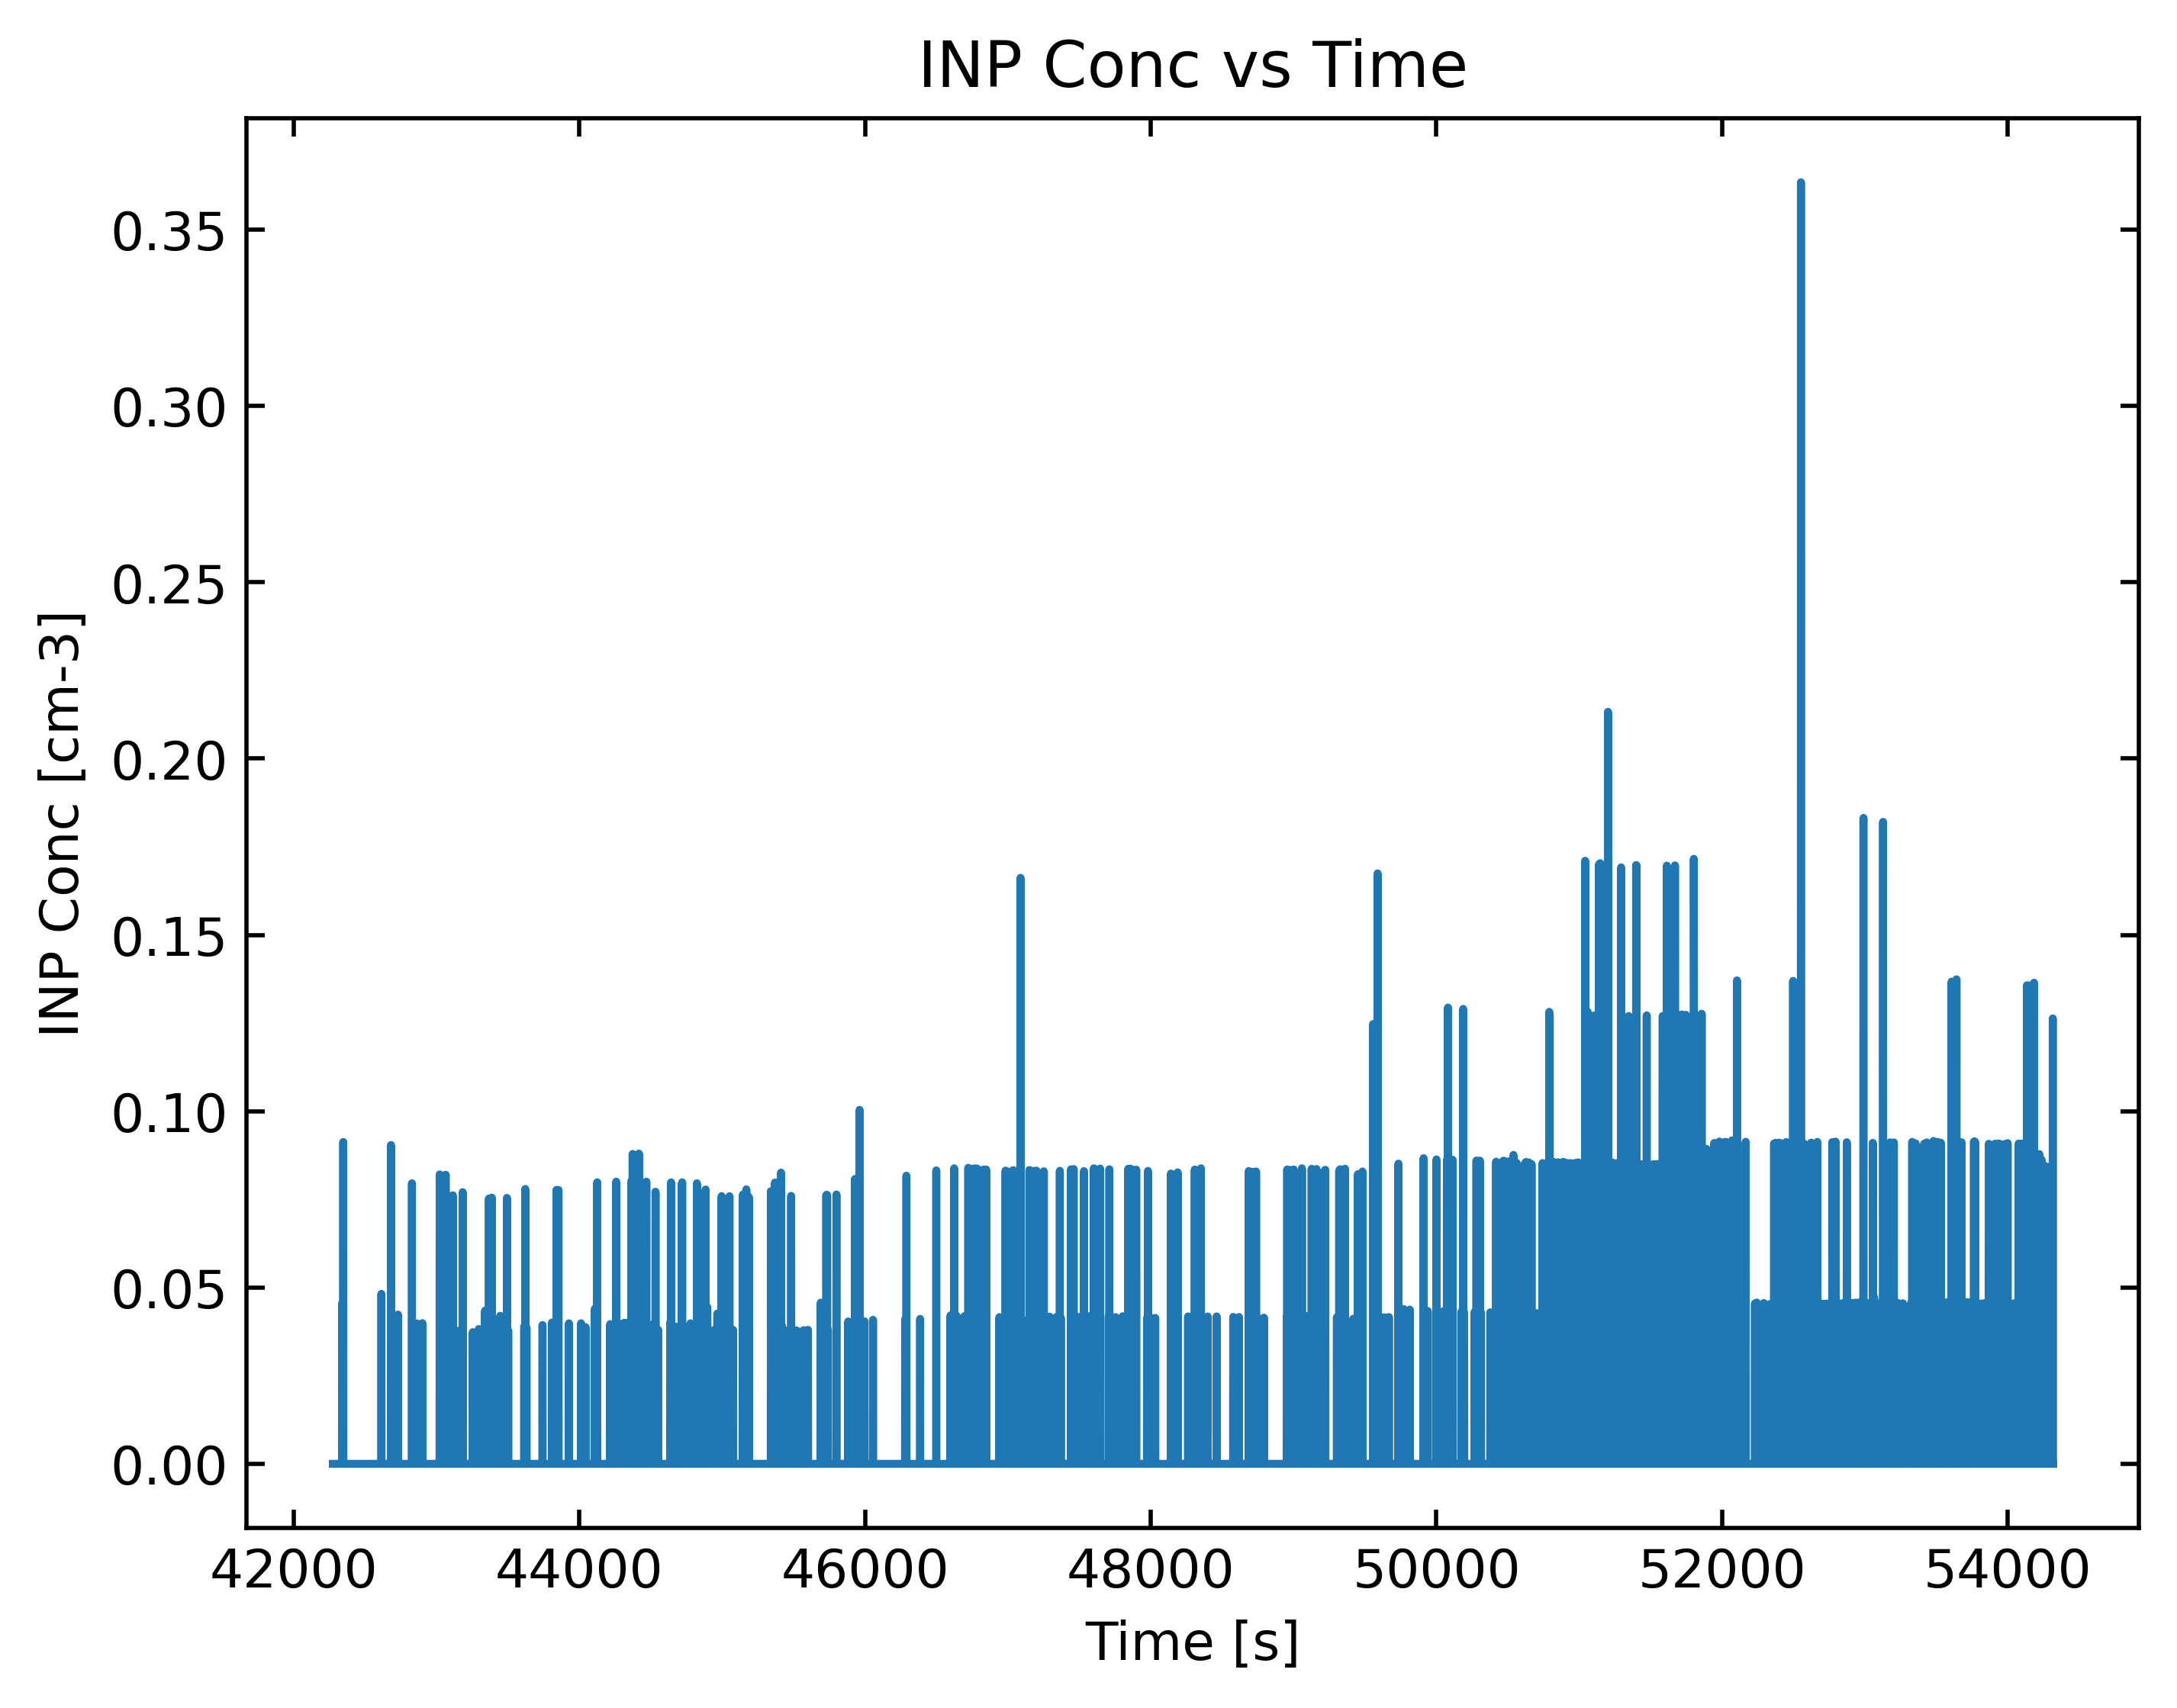

In [39]:
# INP Conc vs Time

x = data['Time']
y = data['INP Conc [cm-3]']

fig = plt.figure(dpi=500)
ax = fig.add_subplot(111)

ax.plot(x, y)

ax.set_xlabel('Time [s]')
ax.set_ylabel('INP Conc [cm-3]')
ax.tick_params(which='both', top=True, bottom=True, left=True, right=True, direction='in')
ax.set_title('INP Conc vs Time')

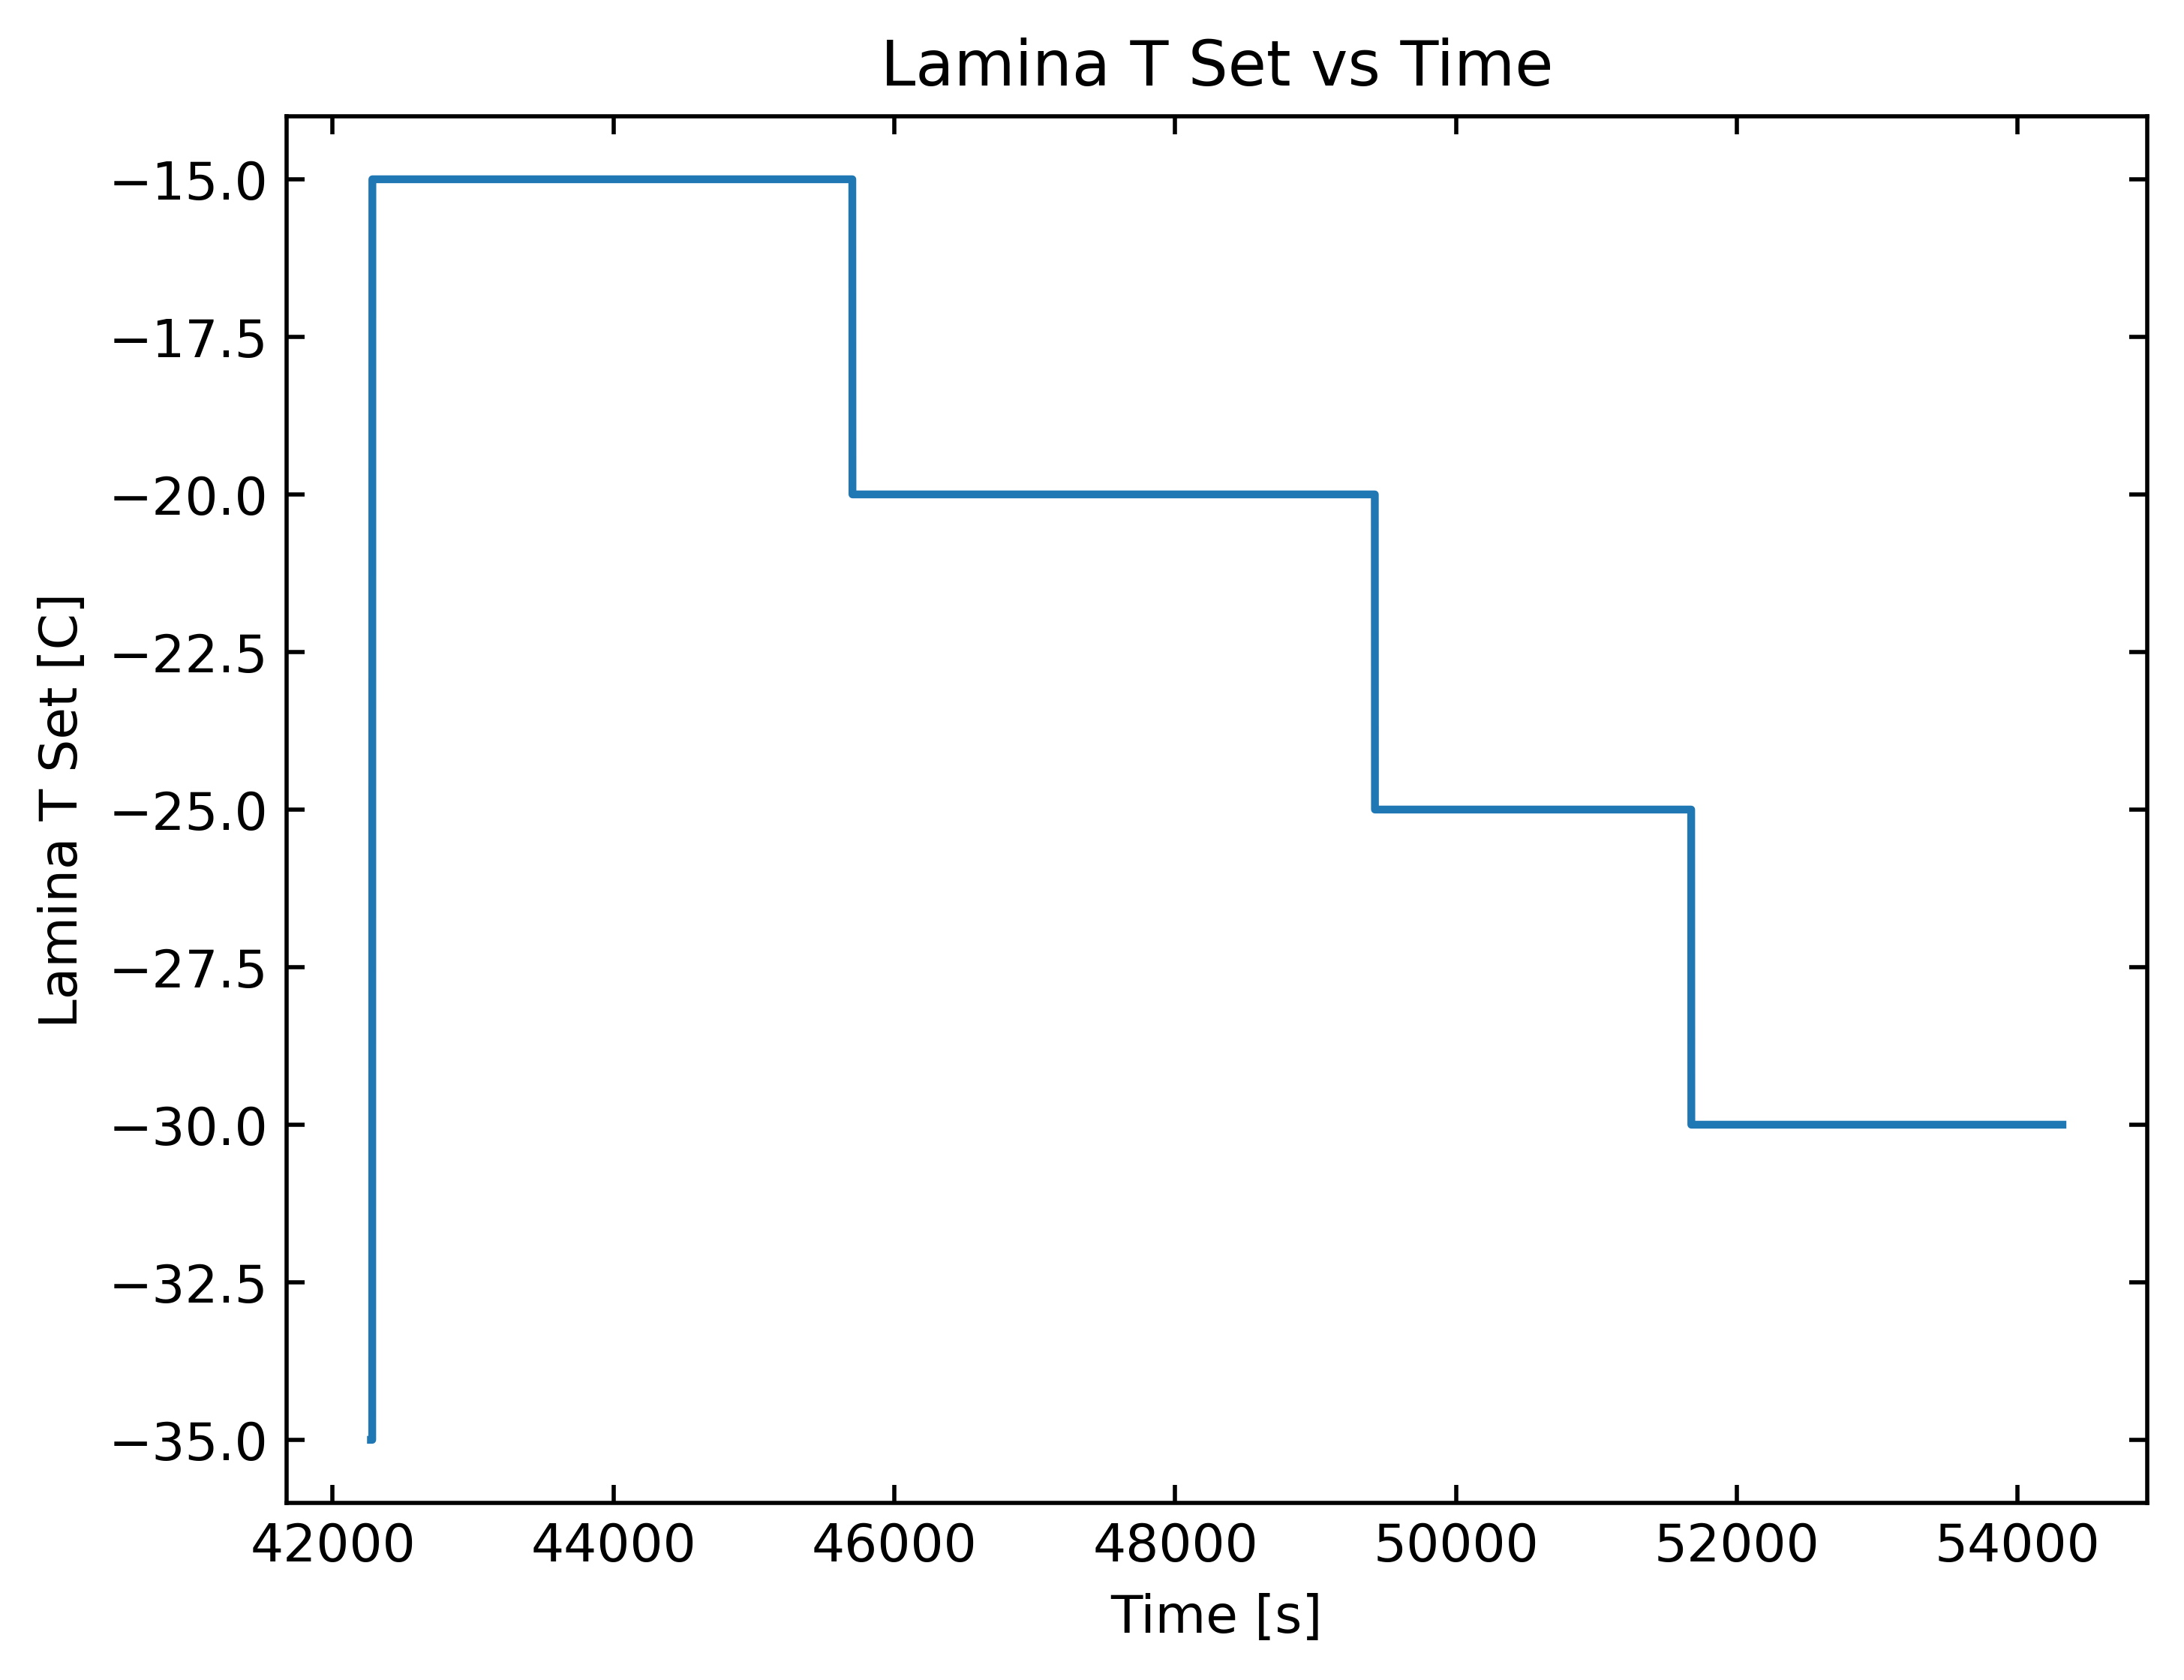

In [40]:
# Lamina T Set vs Time

x = data['Time']
y = data['Lamina T Set [C]']

fig = plt.figure(dpi=500)
ax = fig.add_subplot(111)

ax.plot(x, y)

ax.set_xlabel('Time [s]')
ax.set_ylabel('Lamina T Set [C]')
ax.tick_params(which='both', top=True, bottom=True, left=True, right=True, direction='in')
ax.set_title('Lamina T Set vs Time')

plt.savefig(r"D:\Coding\master0_2025\Lanzhou_cfdc\Lamina_T_Set_vs_Time.png", bbox_inches='tight')

Text(0.5, 1.0, 'T difference vs Time')

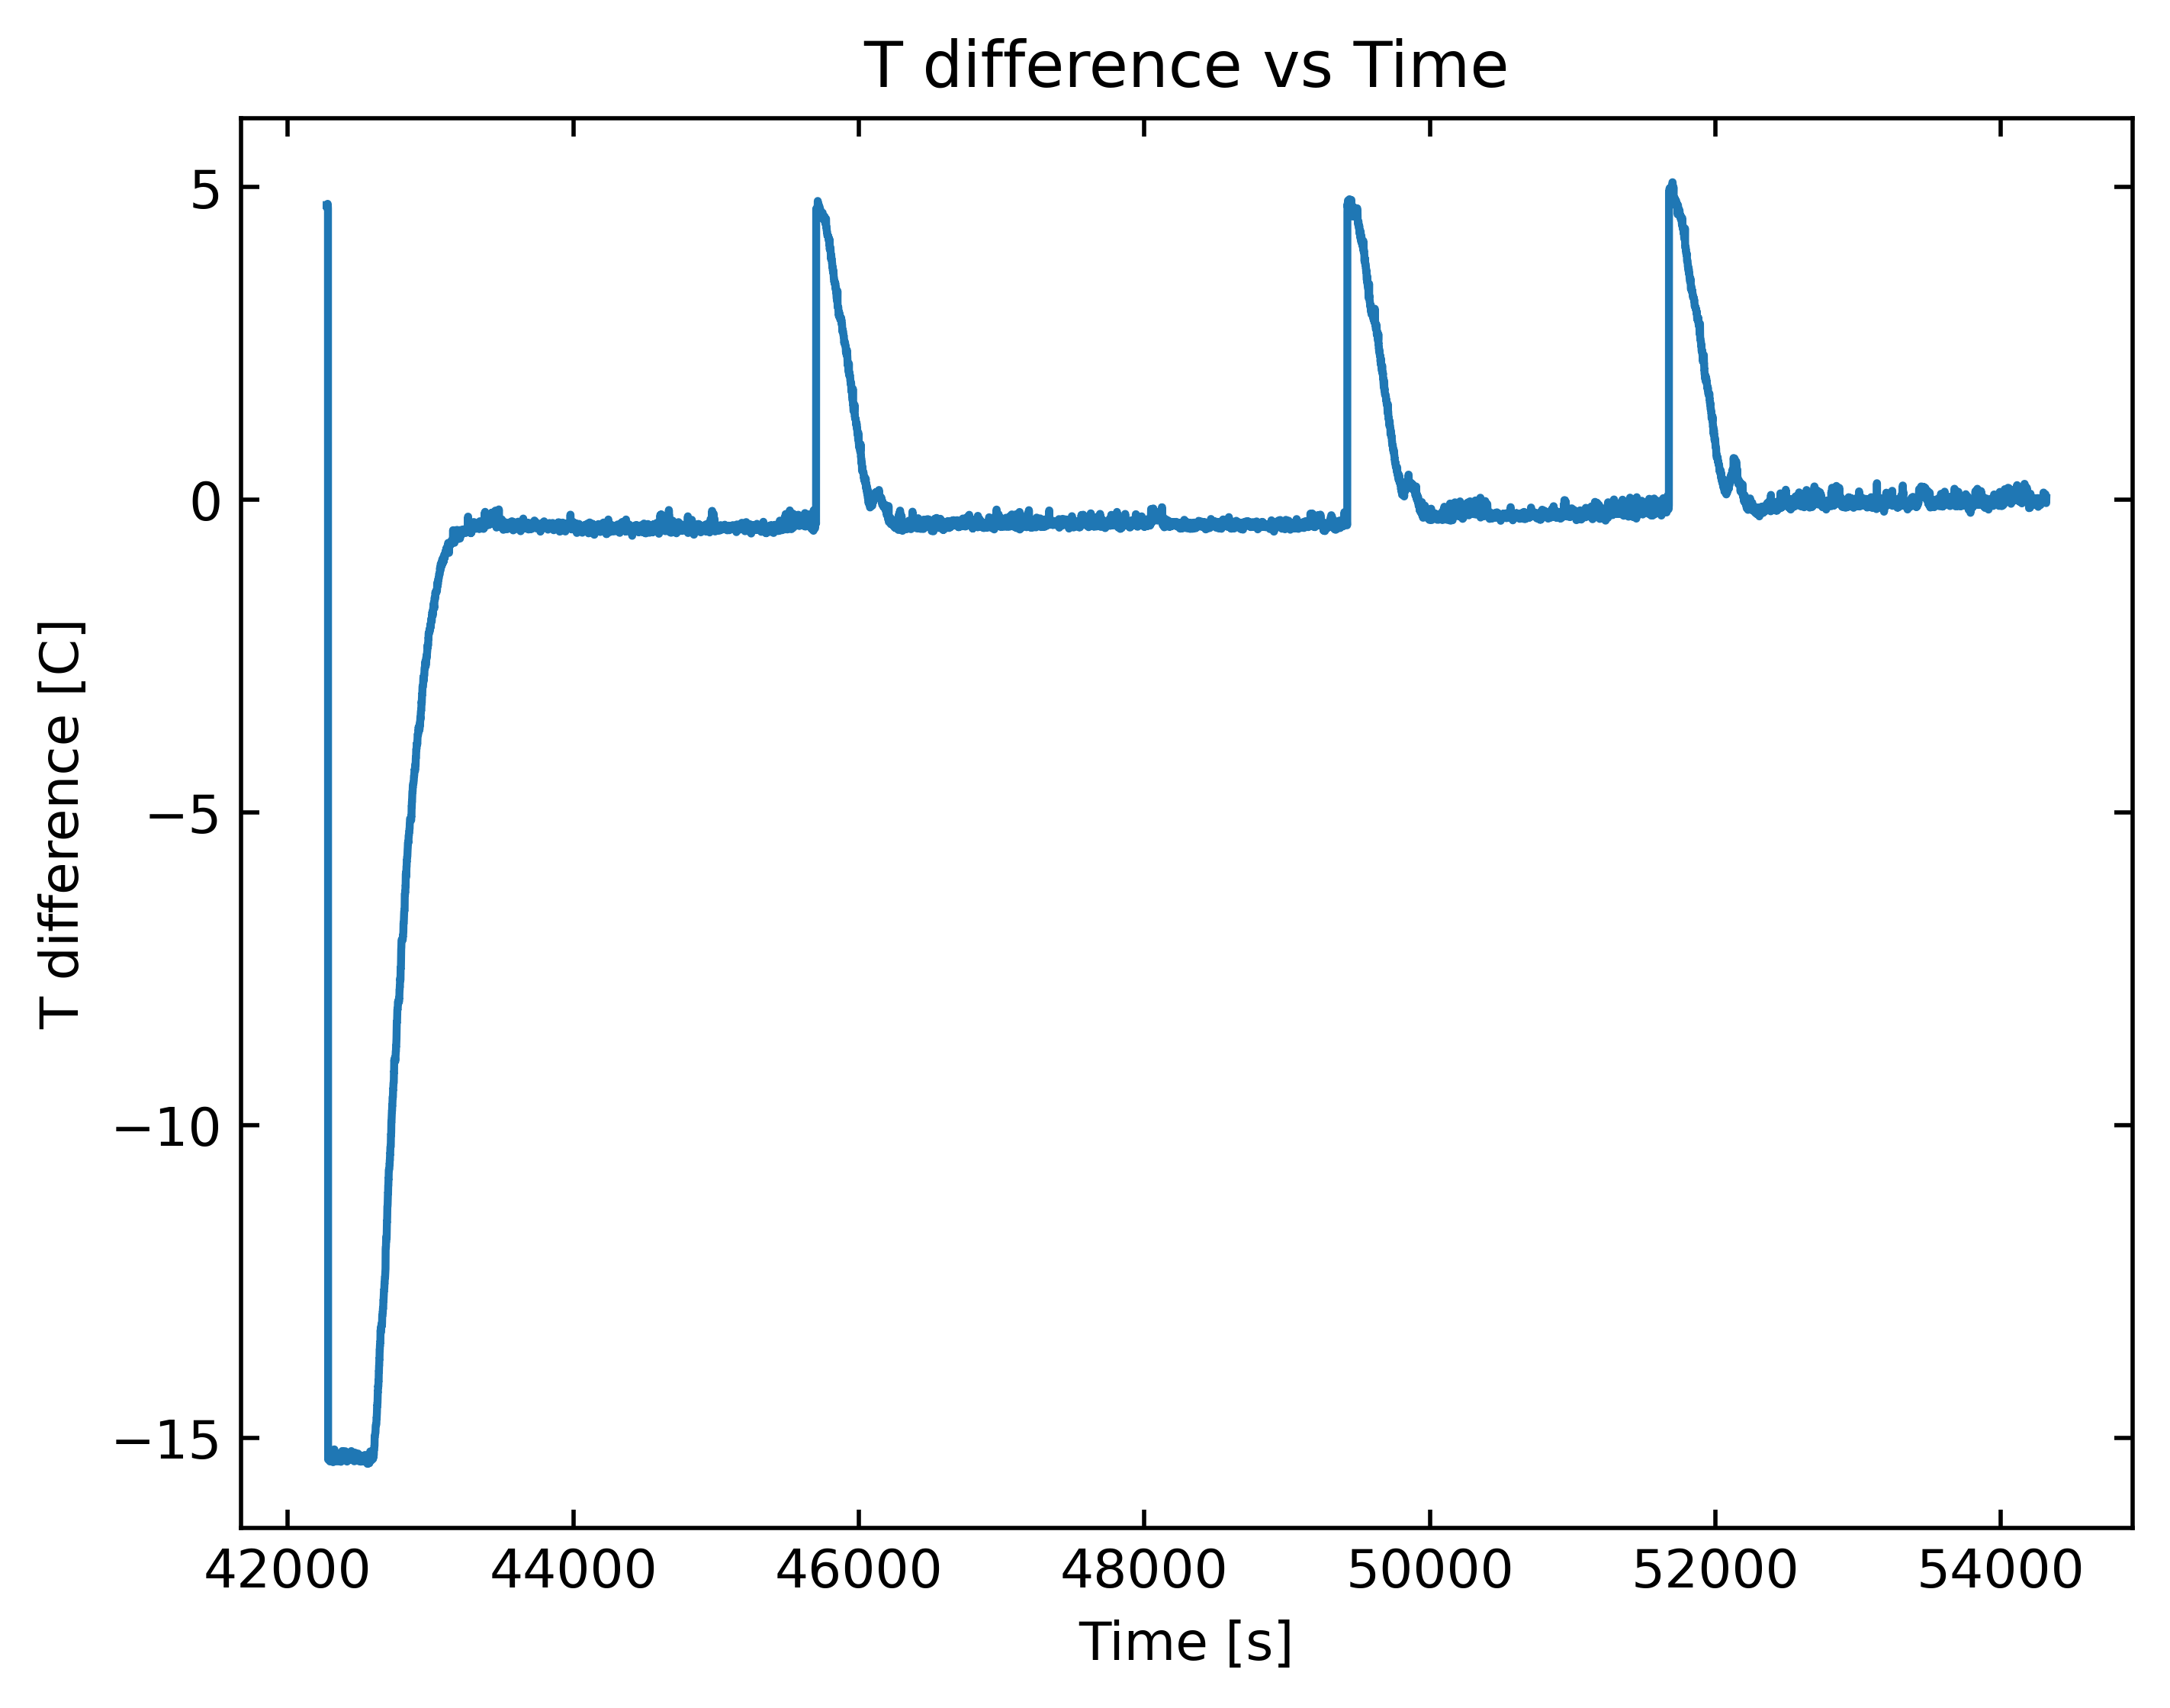

In [41]:
# T difference vs Time

x = data['Time']
y = data['Lamina Average T [C]'] - data['Lamina T Set [C]']

fig = plt.figure(dpi=500)
ax = fig.add_subplot(111)

ax.plot(x, y)

ax.set_xlabel('Time [s]')
ax.set_ylabel('T difference [C]')
ax.tick_params(which='both', top=True, bottom=True, left=True, right=True, direction='in')
ax.set_title('T difference vs Time')

In [42]:
# 现在的问题是, 我不需要画出整个时间序列, 只需要画出某一段时间的, 满足特定条件的时间段即可.
# 也就是说, 在使用Pandas读取csv文件后, 如何对数据进行筛选?

print(y)
print(abs(y) < 0.1)
print(y[abs(y) < 0.1])

11956    4.711498
11957    4.711498
11958    4.668445
11959    4.721384
11960    4.721384
           ...   
23998   -0.030249
23999    0.020907
24000   -0.052777
24001   -0.052777
24002    0.028024
Length: 12047, dtype: float64
11956    False
11957    False
11958    False
11959    False
11960    False
         ...  
23998     True
23999     True
24000     True
24001     True
24002     True
Length: 12047, dtype: bool
15744    0.085942
15746    0.069667
15747    0.024514
15748    0.024514
15749    0.070236
           ...   
23998   -0.030249
23999    0.020907
24000   -0.052777
24001   -0.052777
24002    0.028024
Length: 2036, dtype: float64


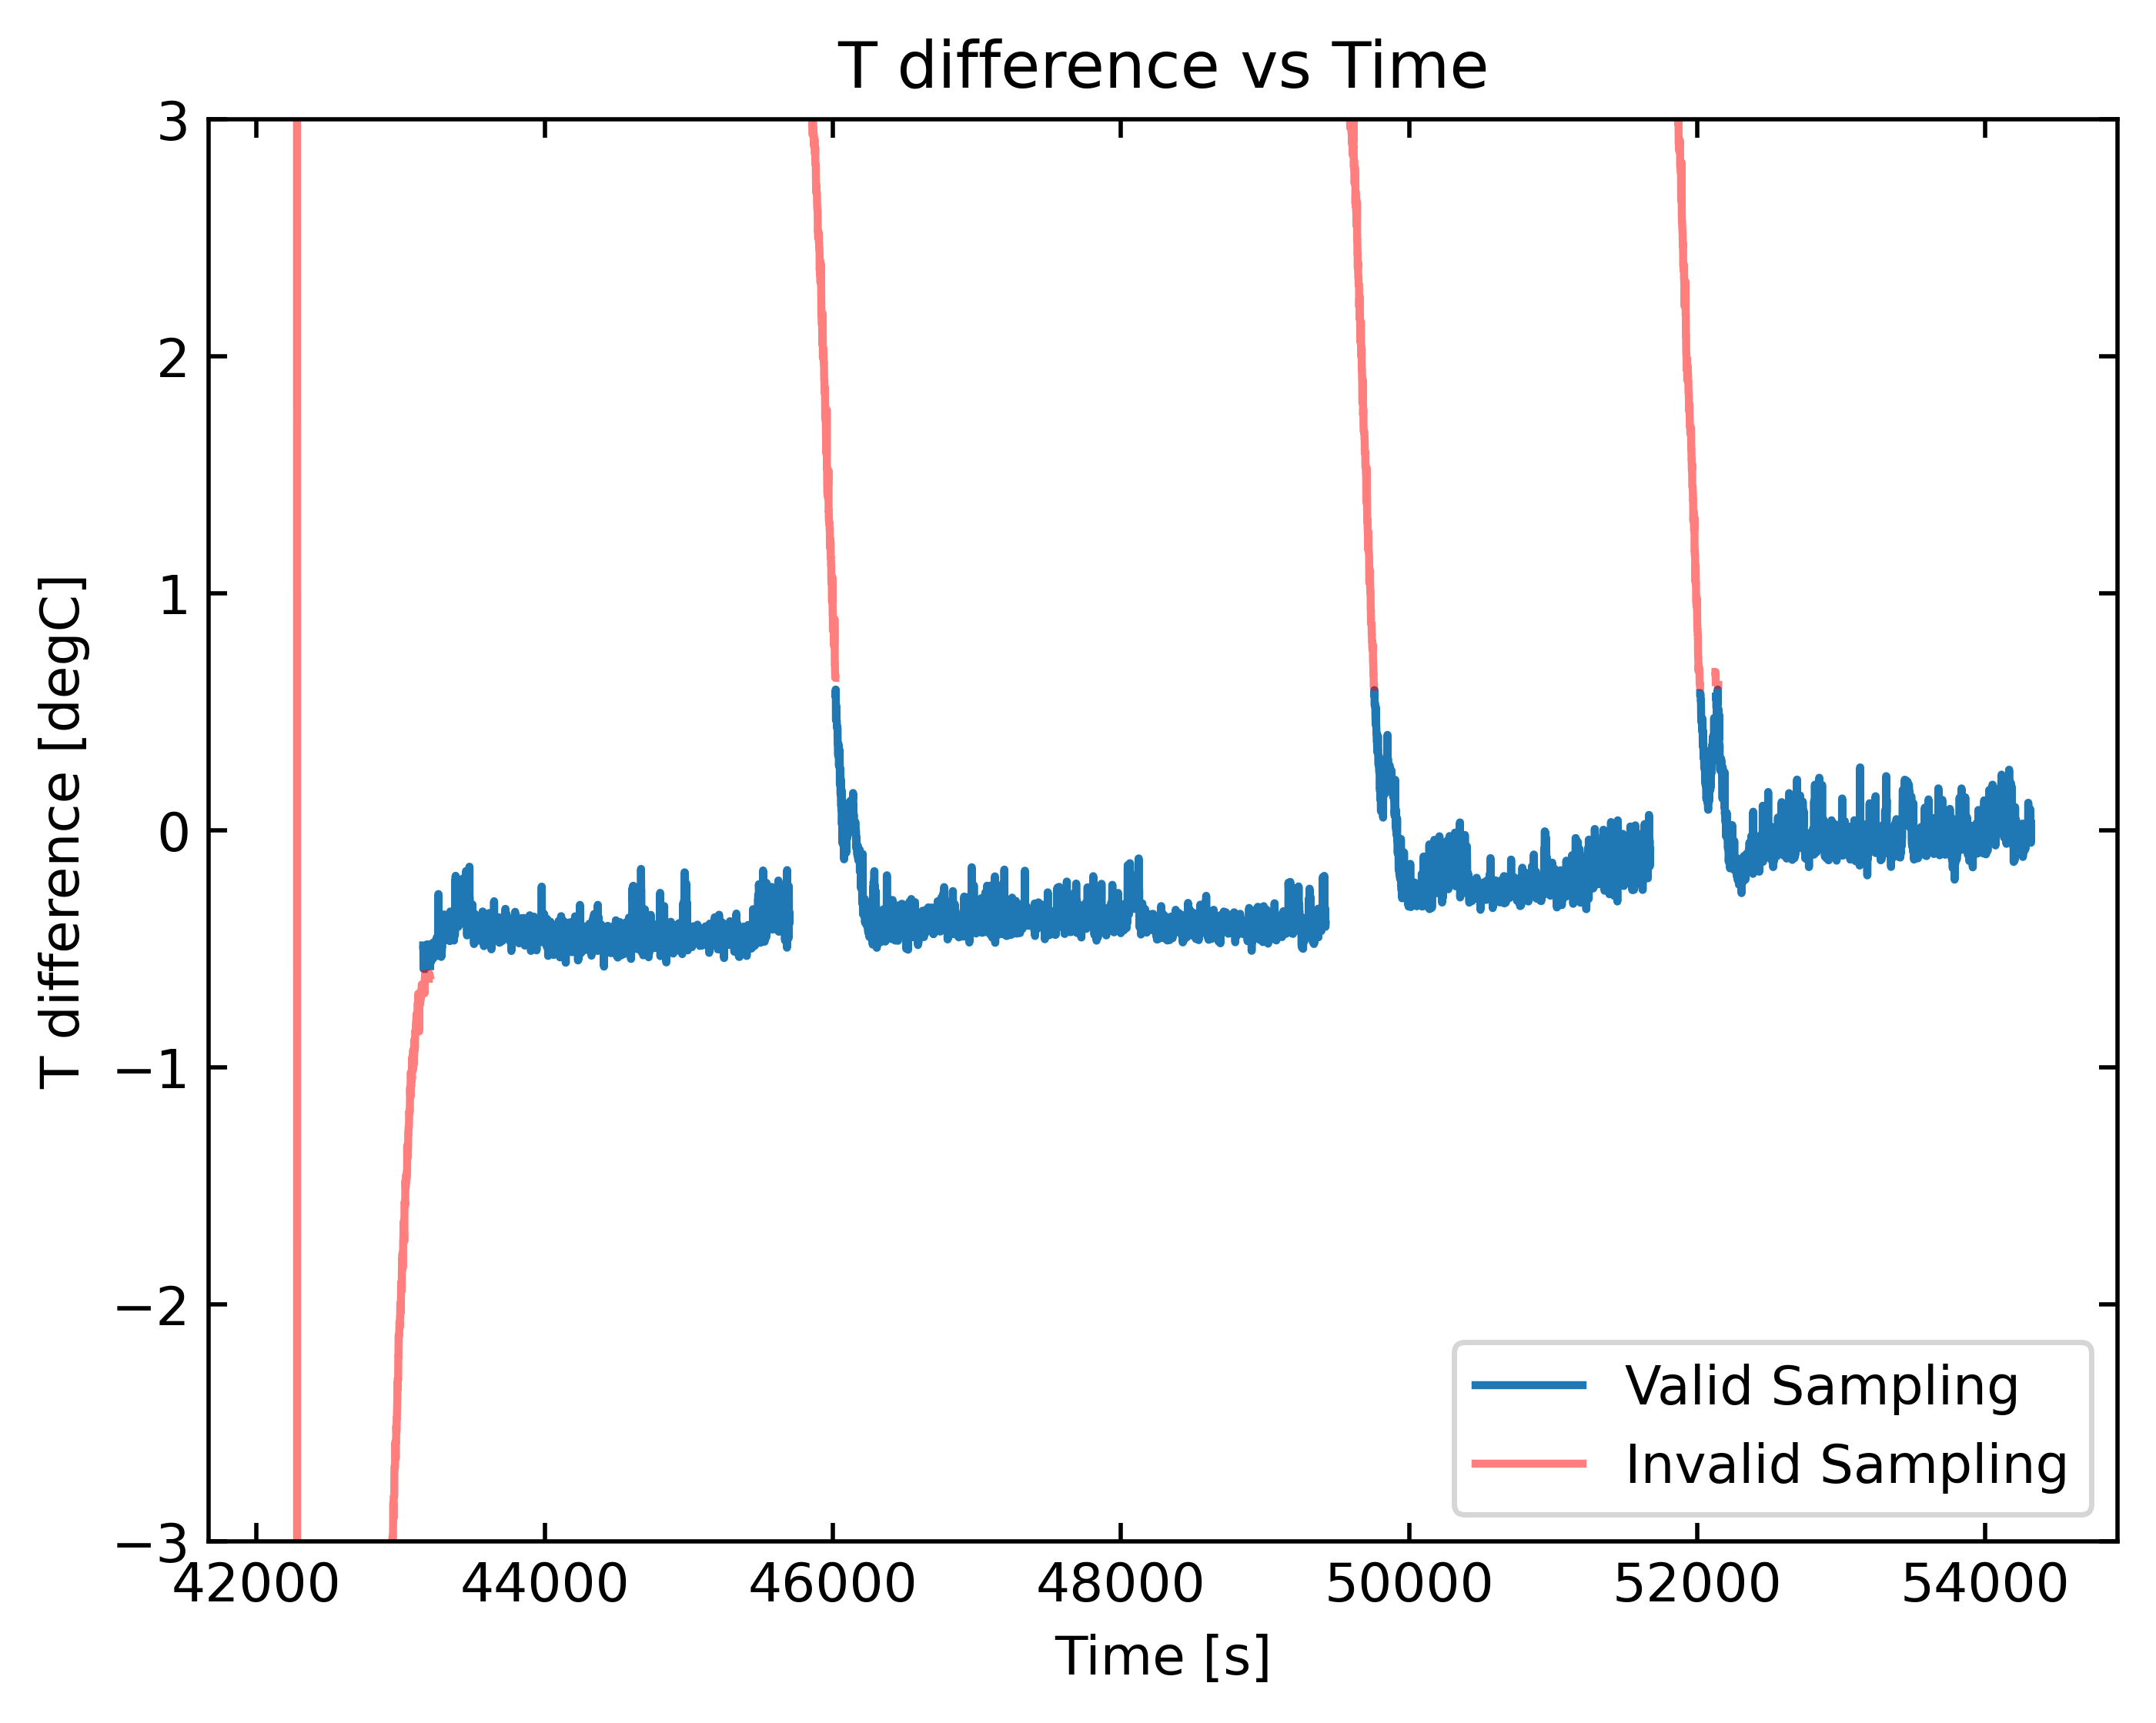

In [43]:
# T difference vs Time

x = data['Time']
y = data['Lamina Average T [C]'] - data['Lamina T Set [C]']

# 认为差不大于0.6degC时，处于有效采样状态
y1 = y[abs(y) <= 0.6].reindex(x.index, fill_value=np.nan)
y2 = y[abs(y) > 0.6].reindex(x.index, fill_value=np.nan)

fig = plt.figure(dpi=500)
ax = fig.add_subplot(111)

ax.plot(x, y1, label='Valid Sampling')
ax.plot(x, y2, label='Invalid Sampling', color='red', alpha=0.5)

ax.set_xlabel('Time [s]')
ax.set_ylabel('T difference [degC]')
ax.tick_params(which='both', top=True, bottom=True, left=True, right=True, direction='in')
ax.set_title('T difference vs Time')
ax.legend()
ax.set_ylim(-3, 3)

# 保存图片
plt.savefig(r"D:\Coding\master0_2025\Lanzhou_cfdc\T_difference_vs_Time.png", bbox_inches='tight')

# 这个差我们应该设定为多少才合理?

In [44]:
df1 = pd.DataFrame(np.arange(12.).reshape((3,4)), columns=['a', 'b', 'c', 'd'], index=['a', 'b', 'c'])
print(df1)
print(df1.apply(lambda x: x - x.mean()))# 这行代码如何理解? 为何是对每一列进行操作? 而下面却是对行进行操作?
print(df1.apply(sum))

     a    b     c     d
a  0.0  1.0   2.0   3.0
b  4.0  5.0   6.0   7.0
c  8.0  9.0  10.0  11.0
     a    b    c    d
a -4.0 -4.0 -4.0 -4.0
b  0.0  0.0  0.0  0.0
c  4.0  4.0  4.0  4.0
a    12.0
b    15.0
c    18.0
d    21.0
dtype: float64


Text(0.5, 1.0, 'INP Conc vs Time')

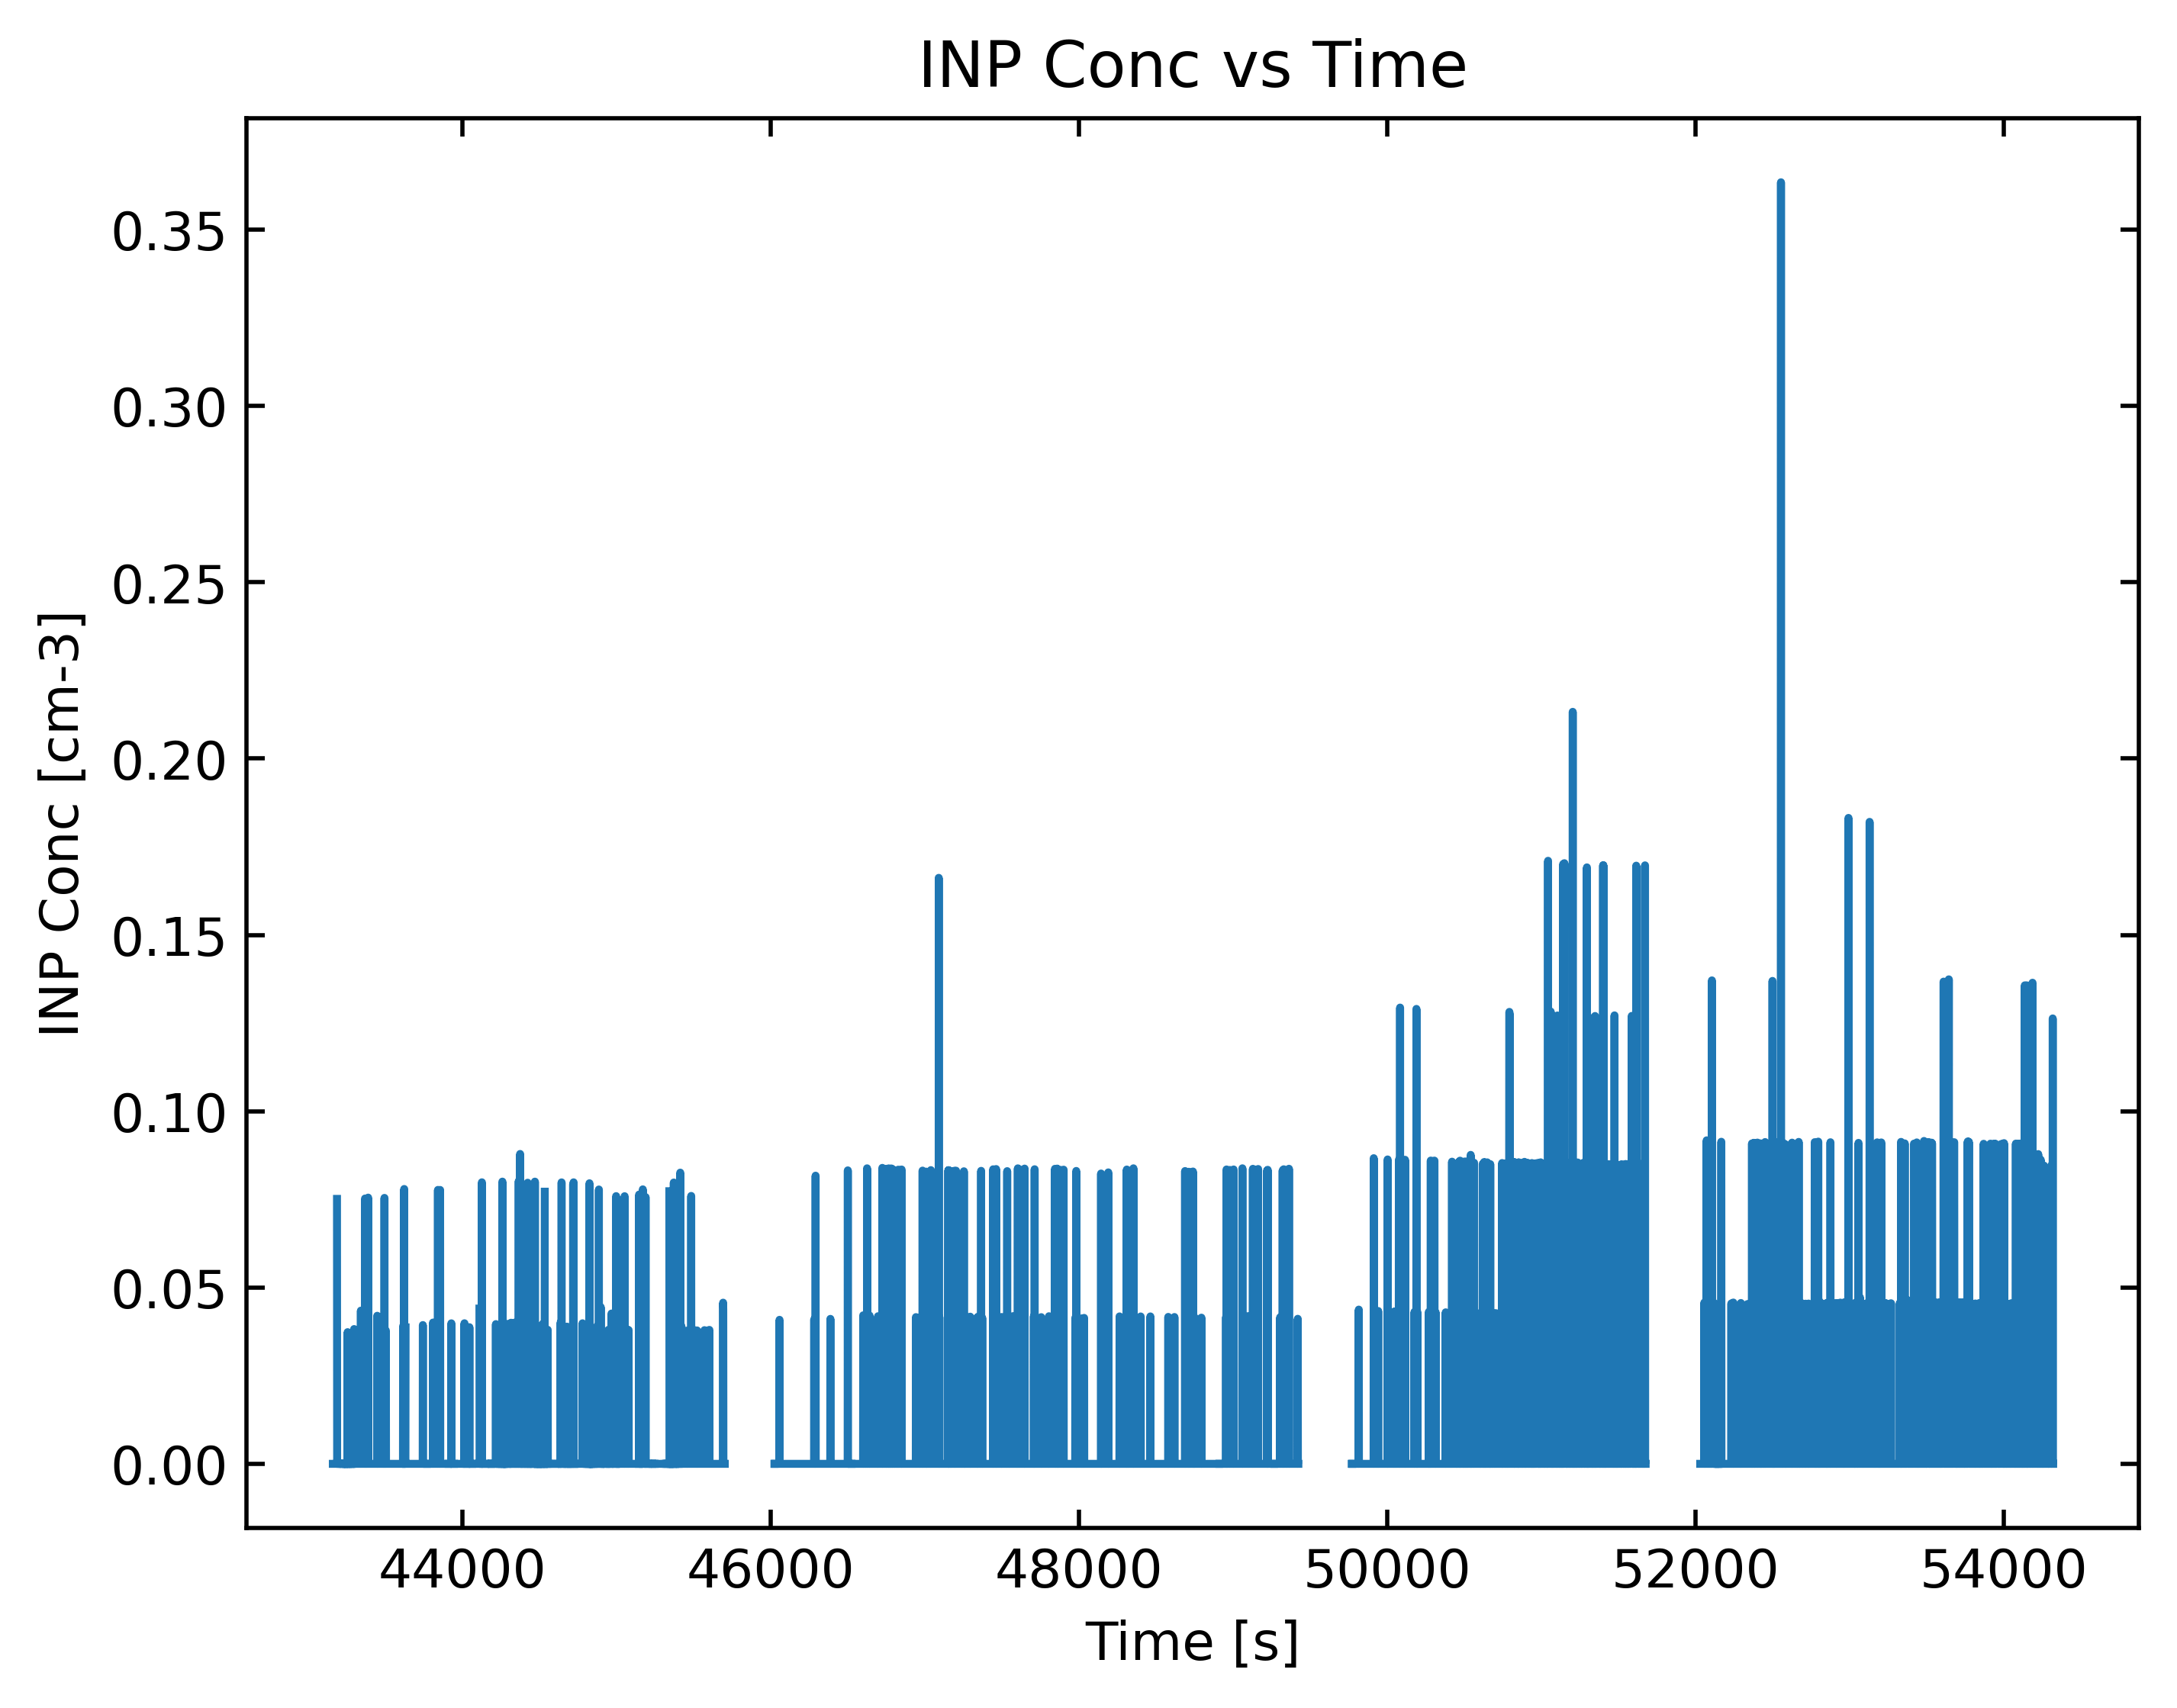

In [45]:
x = data['Time']
y = data['INP Conc [cm-3]']
diff = data['Lamina Average T [C]'] - data['Lamina T Set [C]']

# 认为差不大于0.5degC时，处于有效采样状态
y = y[abs(diff) < 0.5].reindex(x.index, fill_value=np.nan)

fig = plt.figure(dpi=500)
ax = fig.add_subplot(111)

ax.plot(x, y)

ax.set_xlabel('Time [s]')
ax.set_ylabel('INP Conc [cm-3]')
ax.tick_params(which='both', top=True, bottom=True, left=True, right=True, direction='in')
ax.set_title('INP Conc vs Time')

Text(0.5, 1.0, 'Inlet Valve vs Time')

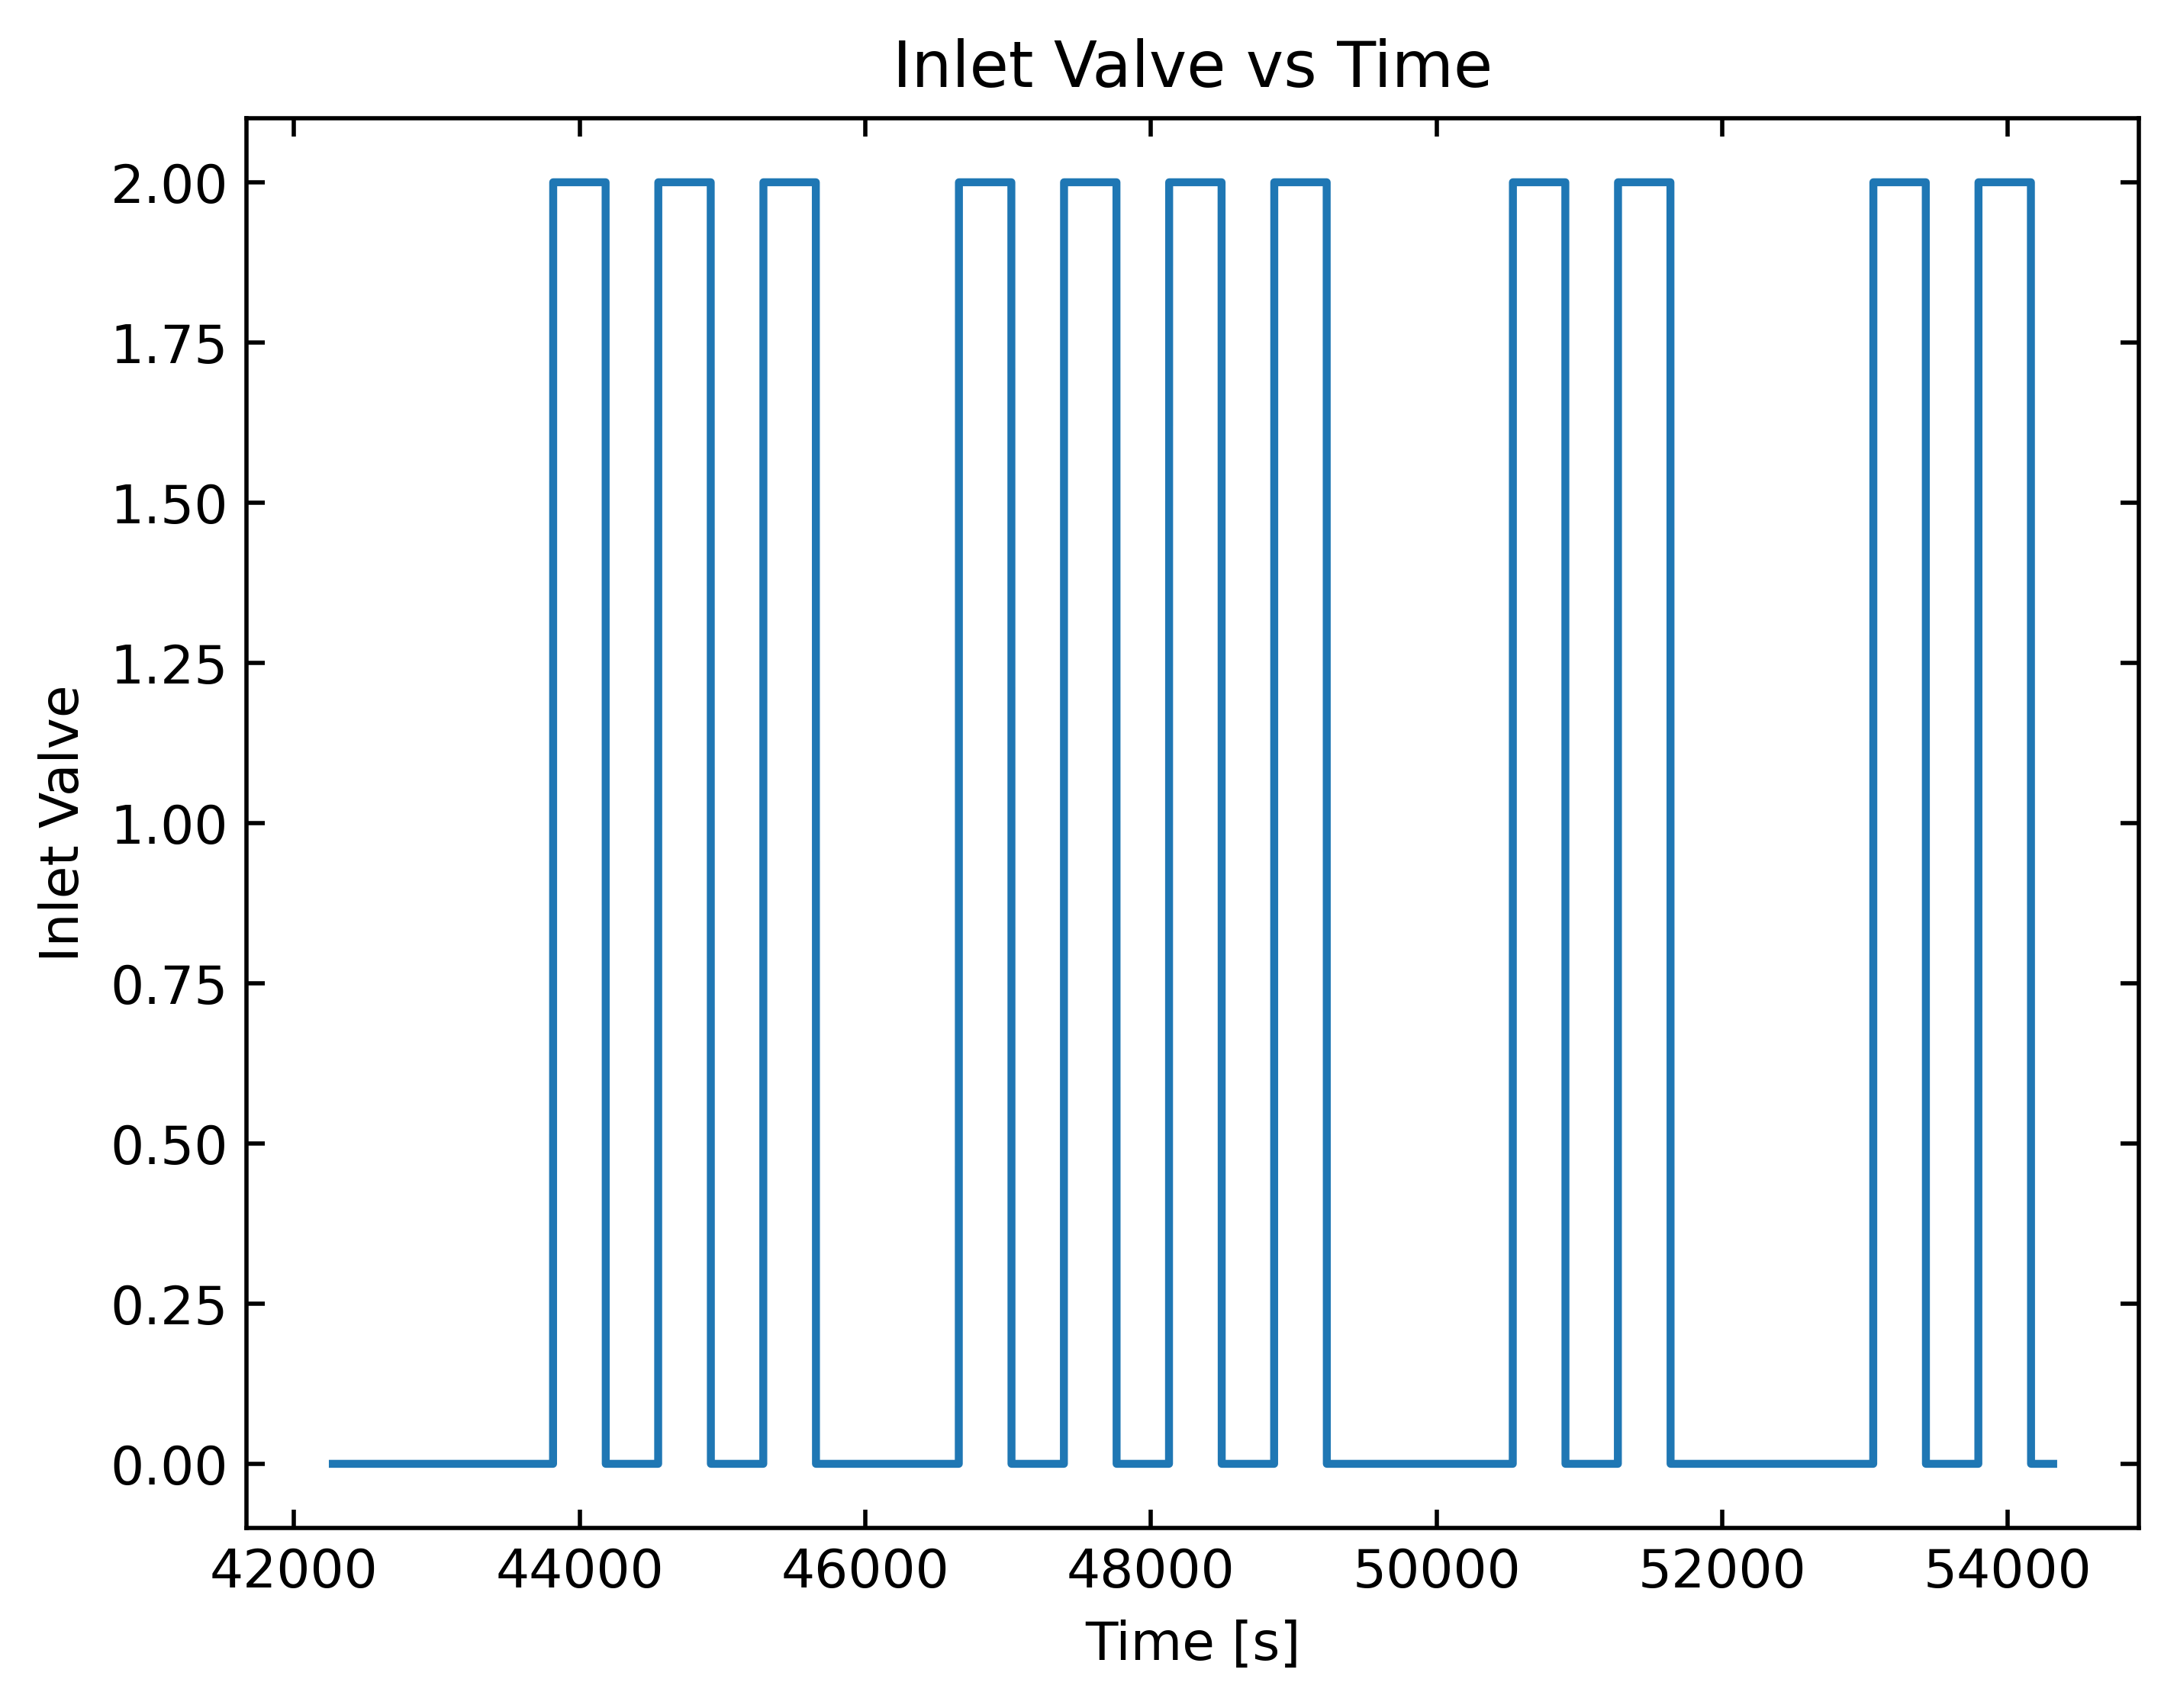

In [46]:
# Inlet Valve vs Time(进气阀变化规律)

x = data['Time']
y = data['Inlet Valve']

fig = plt.figure(dpi=500)
ax = fig.add_subplot(111)

ax.plot(x, y)

ax.set_xlabel('Time [s]')
ax.set_ylabel('Inlet Valve')
ax.tick_params(which='both', top=True, bottom=True, left=True, right=True, direction='in')
ax.set_title('Inlet Valve vs Time')

Text(0.5, 1.0, 'N2 [SLPM] vs Time')

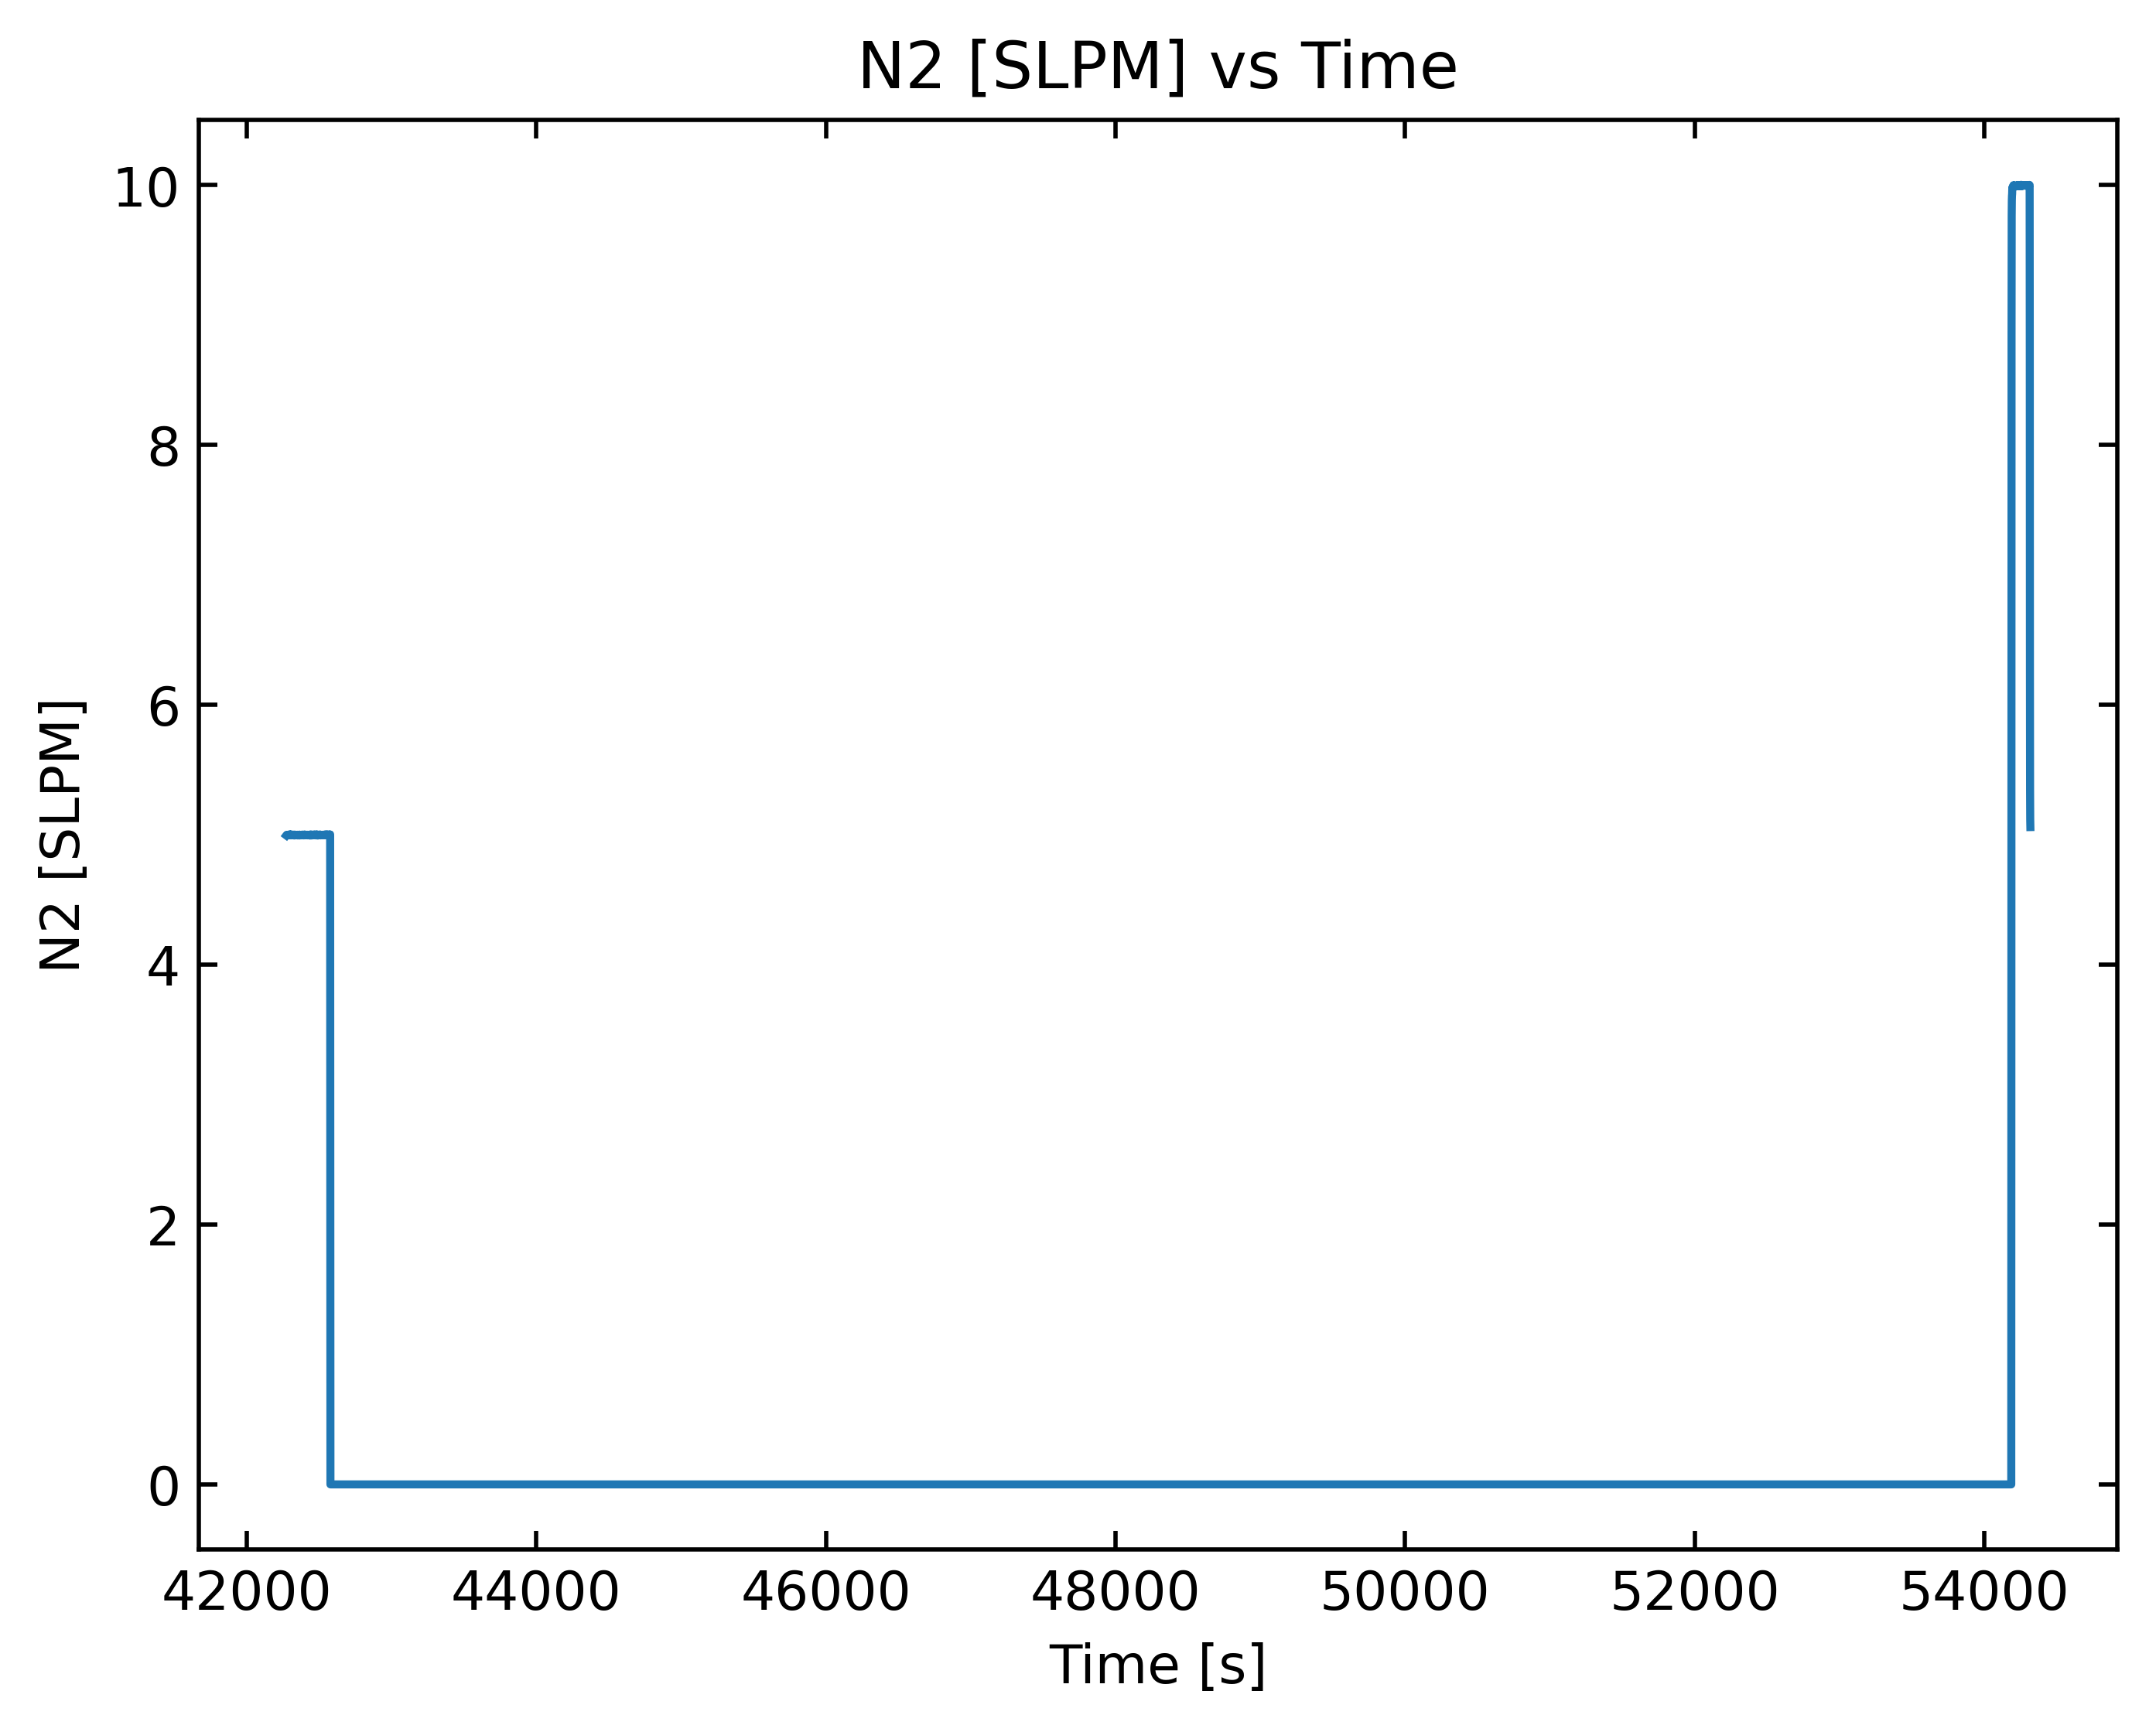

In [47]:
# N2 [SLPM] vs Time(氮气流量变化规律)

x = data['Time']
y = data['N2 [SLPM]']

fig = plt.figure(dpi=500)
ax = fig.add_subplot(111)

ax.plot(x, y)

ax.set_xlabel('Time [s]')
ax.set_ylabel('N2 [SLPM]')
ax.tick_params(which='both', top=True, bottom=True, left=True, right=True, direction='in')
ax.set_title('N2 [SLPM] vs Time')


Text(0.5, 1.0, 'N Packets vs Time')

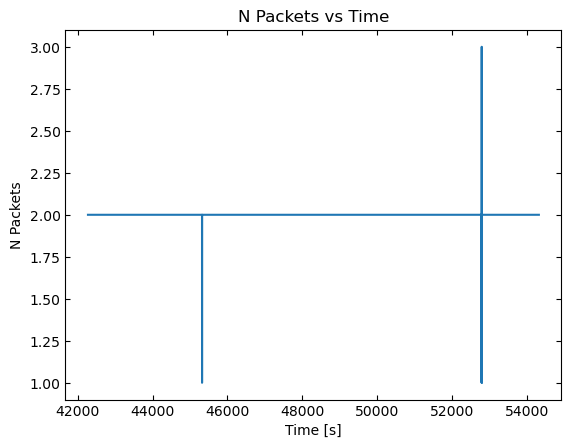

In [48]:
# N Packets vs Time

x = data['Time']
y = data['N Packets']

fig = plt.figure()
ax = fig.add_subplot(111)

ax.plot(x, y)

ax.set_xlabel('Time [s]')
ax.set_ylabel('N Packets')
ax.tick_params(which='both', top=True, bottom=True, left=True, right=True, direction='in')
ax.set_title('N Packets vs Time')

Text(0.5, 1.0, 'INP avg [#/L] Toggle vs Time')

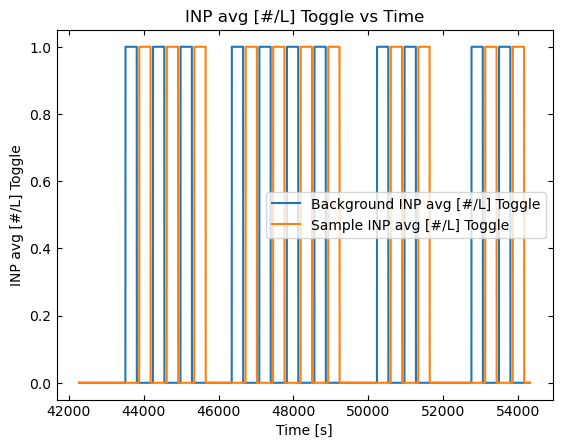

In [49]:
# Background INP avg [#/L] Toggle and Sample INP avg [#/L] Toggle vs Time

x = data['Time']
y1 = data['Background INP avg [#/L] Toggle'].replace(['TRUE', 'FALSE'], [1, 0])
y2 = data['Sample INP avg [#/L] Toggle'].replace(['TRUE', 'FALSE'], [1, 0])

fig = plt.figure()
ax = fig.add_subplot(111)

ax.plot(x, y1, label='Background INP avg [#/L] Toggle')
ax.plot(x, y2, label='Sample INP avg [#/L] Toggle')

ax.legend()
ax.set_xlabel('Time [s]')
ax.set_ylabel('INP avg [#/L] Toggle')
ax.tick_params(which='both', top=True, bottom=True, left=True, right=True, direction='in')
ax.set_title('INP avg [#/L] Toggle vs Time')

count    3333.000000
mean        5.009726
std         6.540518
min         0.000000
25%         1.514110
50%         3.286935
75%         5.694856
max       166.184201
Name: Background INP avg [#/L], dtype: float64


Text(0.5, 1.0, 'INP avg [#/L] vs Time')

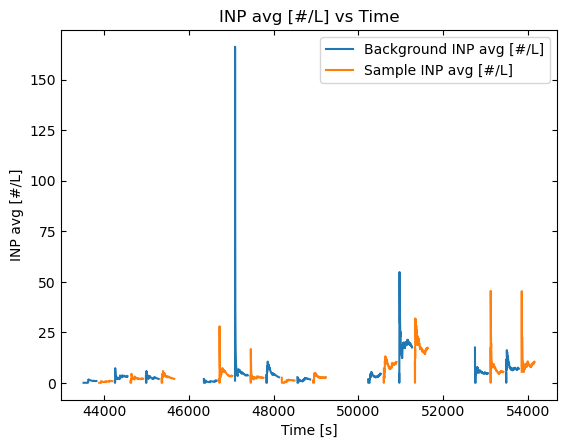

In [50]:
# Background INP avg [#/L] vs Time

x = data['Time']
diff = data['Lamina Average T [C]'] - data['Lamina T Set [C]']
background_toggle = data['Background INP avg [#/L] Toggle']
sample_toggle = data['Sample INP avg [#/L] Toggle']
y1 = data['Background INP avg [#/L]'][background_toggle==True][abs(diff) <= 0.6].reindex(x.index, fill_value=np.nan)
y2 = data['Sample INP avg [#/L]'][sample_toggle==True][abs(diff) <= 0.6].reindex(x.index, fill_value=np.nan)

print(y1.describe())

fig = plt.figure()
ax = fig.add_subplot(111)

ax.plot(x, y1, label='Background INP avg [#/L]')
ax.plot(x, y2, label='Sample INP avg [#/L]')

ax.legend()
ax.set_xlabel('Time [s]')
ax.set_ylabel('INP avg [#/L]')
ax.tick_params(which='both', top=True, bottom=True, left=True, right=True, direction='in')
ax.set_title('INP avg [#/L] vs Time')

# 47088s时, 为什么数据文件中, Total OPC = 3 小于 INP Counts = 4 ?

In [5]:
base_date = pd.to_datetime("2025-01-20")

dt = base_date + pd.to_timedelta(data['Time'], unit='s')

out_dt = dt.dt.strftime("%m.%d.%Y %H:%M")

Text(0.5, 1.0, 'INP avg [#/L] vs Time')

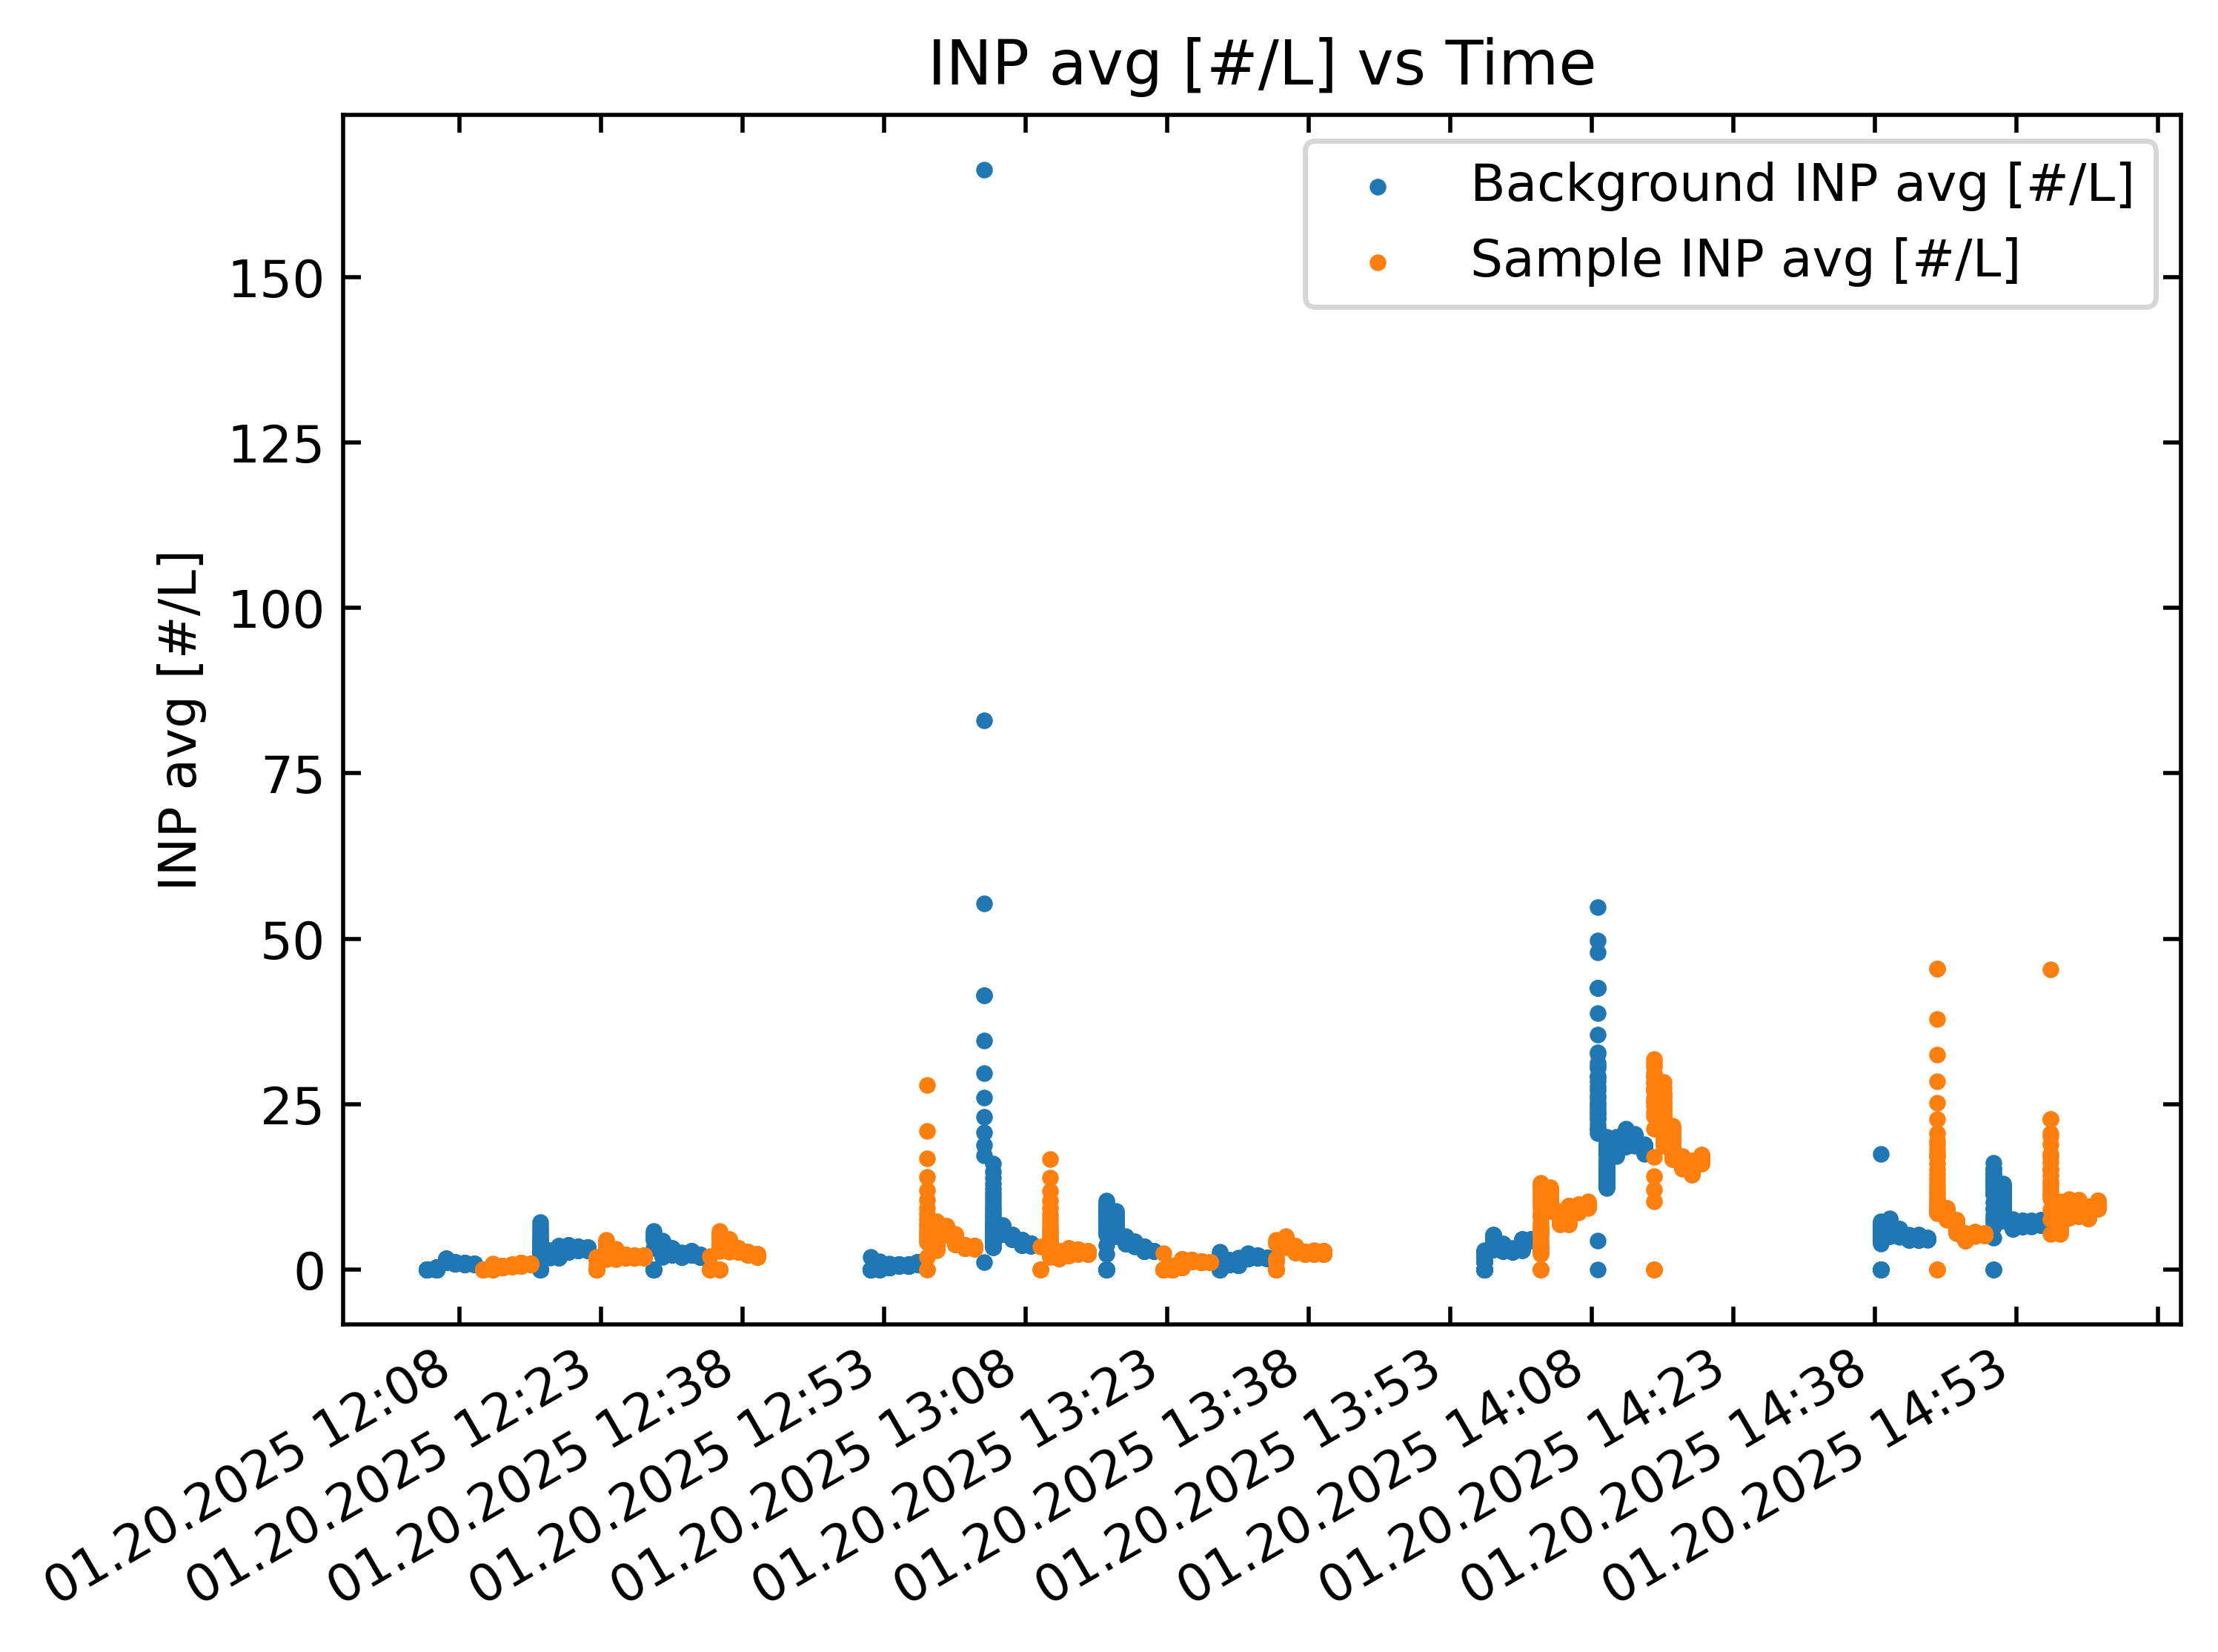

In [10]:
# Background INP avg [#/L] vs Time

import matplotlib.dates as mdates

x = out_dt
diff = data['Lamina Average T [C]'] - data['Lamina T Set [C]']
background_toggle = data['Background INP avg [#/L] Toggle']
sample_toggle = data['Sample INP avg [#/L] Toggle']
y1 = data['Background INP avg [#/L]'][background_toggle==True][abs(diff) <= 0.6].reindex(x.index, fill_value=np.nan)
y2 = data['Sample INP avg [#/L]'][sample_toggle==True][abs(diff) <= 0.6].reindex(x.index, fill_value=np.nan)

fig = plt.figure(dpi=500)
ax = fig.add_subplot(111)

ax.scatter(x, y1, label='Background INP avg [#/L]', s=5)
ax.scatter(x, y2, label='Sample INP avg [#/L]', s=5)

ax.legend()
#ax.set_xlabel('Time [s]')
ax.set_ylabel('INP avg [#/L]')
ax.xaxis.set_major_locator(mdates.HourLocator(interval=360))# 为什么这里是每15分钟一个刻度?
plt.gcf().autofmt_xdate()# 自动旋转日期标记
ax.tick_params(which='both', top=True, bottom=True, left=True, right=True, direction='in')
ax.set_title('INP avg [#/L] vs Time')

In [53]:
print(dt)
print(out_dt)

11956   2025-01-20 11:44:32.299682
11957   2025-01-20 11:44:33.299976
11958   2025-01-20 11:44:34.300139
11959   2025-01-20 11:44:35.300267
11960   2025-01-20 11:44:36.299484
                   ...            
23998   2025-01-20 15:05:14.300855
23999   2025-01-20 15:05:15.299291
24000   2025-01-20 15:05:16.300926
24001   2025-01-20 15:05:17.299587
24002   2025-01-20 15:05:18.300866
Name: Time, Length: 12047, dtype: datetime64[ns]
11956    01.20.2025 11:44
11957    01.20.2025 11:44
11958    01.20.2025 11:44
11959    01.20.2025 11:44
11960    01.20.2025 11:44
               ...       
23998    01.20.2025 15:05
23999    01.20.2025 15:05
24000    01.20.2025 15:05
24001    01.20.2025 15:05
24002    01.20.2025 15:05
Name: Time, Length: 12047, dtype: object


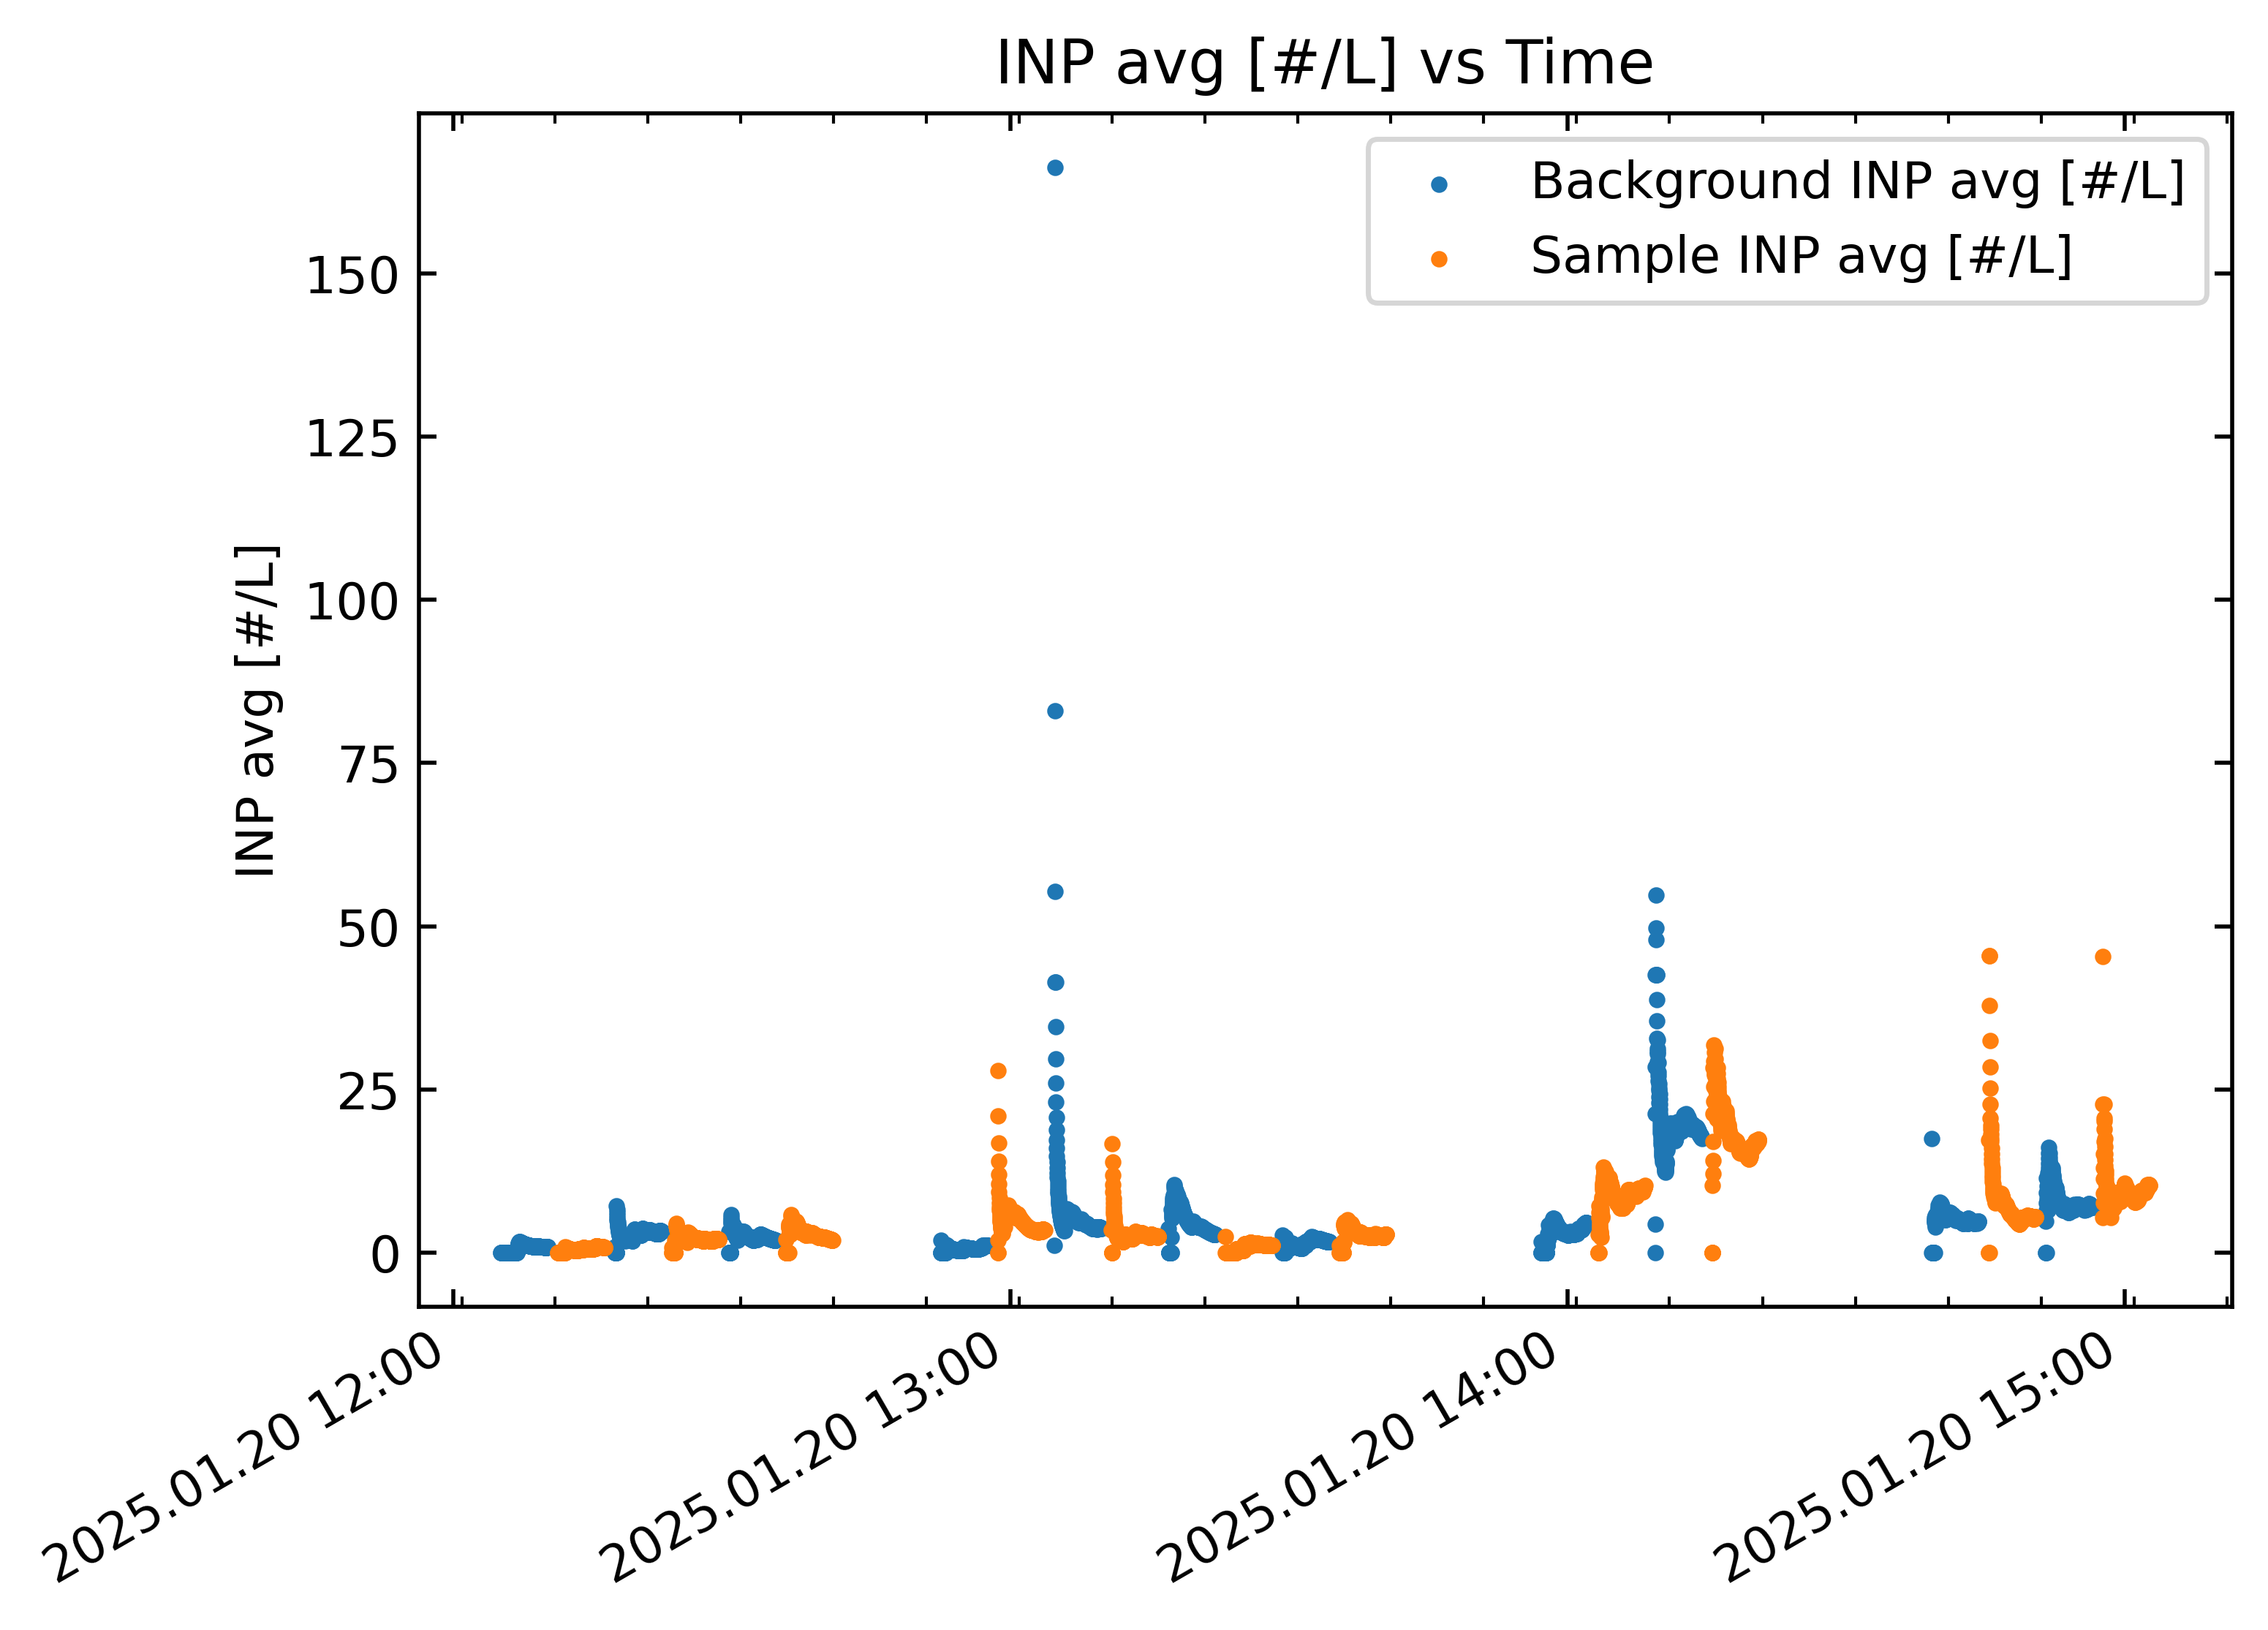

In [12]:
# 整合画出一天INP浓度的时间序列

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

#一天数据集处理
data = pd.read_csv(r"D:\Coding\Data\Lanzhou_cfdc\test\data_20250120T082513.csv")
data = data.dropna(subset=['Lamina Average T [C]'])

#根据文件名确定当天日期
base_date = pd.to_datetime("2025-01-20")

dt = base_date + pd.to_timedelta(data['Time'], unit='s')

x = dt
diff = data['Lamina Average T [C]'] - data['Lamina T Set [C]']
background_toggle = data['Background INP avg [#/L] Toggle']
sample_toggle = data['Sample INP avg [#/L] Toggle']
y1 = data['Background INP avg [#/L]'][background_toggle==True][abs(diff) <= 0.6].reindex(x.index, fill_value=np.nan)
y2 = data['Sample INP avg [#/L]'][sample_toggle==True][abs(diff) <= 0.6].reindex(x.index, fill_value=np.nan)

fig = plt.figure(dpi=500)
ax = fig.add_subplot(111)

ax.scatter(x, y1, label='Background INP avg [#/L]', s=5)
ax.scatter(x, y2, label='Sample INP avg [#/L]', s=5)

ax.xaxis.set_major_locator(mdates.HourLocator(interval=1)) # 每小时一个主刻度
ax.xaxis.set_minor_locator(mdates.MinuteLocator(interval=10)) # 每10分钟一个次刻度
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y.%m.%d %H:%M"))
plt.gcf().autofmt_xdate()# 自动旋转日期标记
ax.set_ylabel('INP avg [#/L]')
ax.tick_params(which='both', top=True, bottom=True, left=True, right=True, direction='in')
ax.set_title('INP avg [#/L] vs Time')
ax.legend()


In [55]:
# 根据文件名确定当天日期
from pathlib import Path

p = Path(r"D:\Coding\Data\Lanzhou_cfdc")
count = 0
base_date = None

for file in p.glob("data_2025*.csv"):
    if base_date is None:
        base_date = pd.to_datetime(file.stem.split('_')[1][0:8])
    elif base_date == pd.to_datetime(file.stem.split('_')[1][0:8]):
        print("date repeated: ", base_date)
        count += 1
    else:
        base_date = pd.to_datetime(file.stem.split('_')[1][0:8])

print("Repeated days: ", count)

# 重复的日期如何处理?

date repeated:  2025-01-16 00:00:00
date repeated:  2025-01-17 00:00:00
date repeated:  2025-01-22 00:00:00
date repeated:  2025-01-22 00:00:00
date repeated:  2025-01-22 00:00:00
date repeated:  2025-01-22 00:00:00
date repeated:  2025-01-24 00:00:00
date repeated:  2025-02-13 00:00:00
date repeated:  2025-02-19 00:00:00
date repeated:  2025-02-20 00:00:00
date repeated:  2025-02-21 00:00:00
date repeated:  2025-03-05 00:00:00
date repeated:  2025-03-08 00:00:00
date repeated:  2025-03-11 00:00:00
date repeated:  2025-03-12 00:00:00
date repeated:  2025-03-22 00:00:00
date repeated:  2025-03-24 00:00:00
date repeated:  2025-03-25 00:00:00
date repeated:  2025-04-05 00:00:00
date repeated:  2025-04-08 00:00:00
date repeated:  2025-04-08 00:00:00
date repeated:  2025-04-08 00:00:00
date repeated:  2025-04-10 00:00:00
date repeated:  2025-04-11 00:00:00
date repeated:  2025-04-12 00:00:00
date repeated:  2025-04-13 00:00:00
date repeated:  2025-04-16 00:00:00
date repeated:  2025-04-18 0

In [56]:
# 比较重复日期的数据, 以删除多余的文件

14232    2.011105
dtype: float64
14600    1.581879
dtype: float64


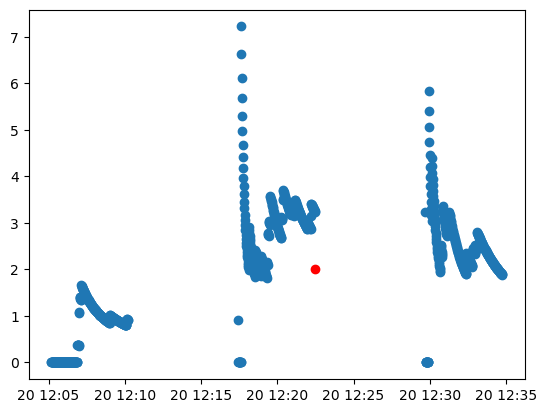

In [14]:
# 数据处理问题

## 数据文件里已经有'Sample INP avg [#/L]'变量, 如果要获取一个测量时间段(背景测量 + 采样)内平均INP浓度,
## 应该采用这个变量的最后一个值, 还是采用这个变量在测量时间段内的平均值?
## 这似乎得看这个变量的计算方法.

### 取最后一个值, 来代表这一个测量时间段内INP浓度

y_bac_15 = data['Background INP avg [#/L]'][background_toggle==True][data['Lamina T Set [C]']==-15.0].reindex(x.index, fill_value=np.nan)
y_sam_15 = data['Sample INP avg [#/L]'][sample_toggle==True][data['Lamina T Set [C]']==-15.0].reindex(x.index, fill_value=np.nan)
#y_bac_15_last = y_bac_15[y_bac_15.notna() & y_bac_15.shift(-1).isna()]
#print(y_bac_15_last)

plt.scatter(x, y_bac_15)
#plt.scatter(x, y_sam_15)
### 得到多个值后, 计算这些值的平均值, 作为该测量时间段的平均INP浓度

#y_bac_15_avg = pd.Series(np.mean(y_bac_15_last.values), index=[np.mean(y_bac_15_last.index).round().astype(int)])
#print(y_bac_15_avg)

### 封装成函数
def compute_avg(s): # 输入一个时间序列, 获取多段时间段(这些时间段由 NaN 隔开)的'最后值', 计算这些'最后值'的平均值, 作为该时间序列的平均值(同时对index取平均)
    s_last = s[s.notna() & s.shift(-1).isna()]
    s_avg = pd.Series(np.mean(s_last.values), index=[np.mean(s_last.index).round().astype(int)])
    return s_avg

y_bac_15_avg = compute_avg(y_bac_15)
y_sam_15_avg = compute_avg(y_sam_15)
print(y_bac_15_avg)
print(y_sam_15_avg)
plt.scatter(x, y_bac_15_avg.reindex(x.index, fill_value=np.nan), c='red')
#plt.scatter(x, y_sam_15_avg.reindex(x.index, fill_value=np.nan))

def compute_net(sam, bac):
    net = sam.values - bac.values
    index = ((bac.index.astype(int) + sam.index.astype(int))/2).astype(int)
    return pd.Series(net, index=index) if net > 0 else pd.Series(0, index=index)

y_net_15_avg = compute_net(y_sam_15_avg, y_bac_15_avg)
#print(y_net_15_avg)
#plt.scatter(x, y_net_15_avg.reindex(x.index, fill_value=np.nan))

13496    0.911658
14232    3.233933
14968    1.887724
Name: Background INP avg [#/L], dtype: float64
Mean Background INP avg [#/L] at -15°C: 2.0111049916707833
Mean Sample INP avg [#/L] at -15°C: 1.5818787037259965
Mean Net INP avg [#/L] at -15°C: -0.4292262879447868


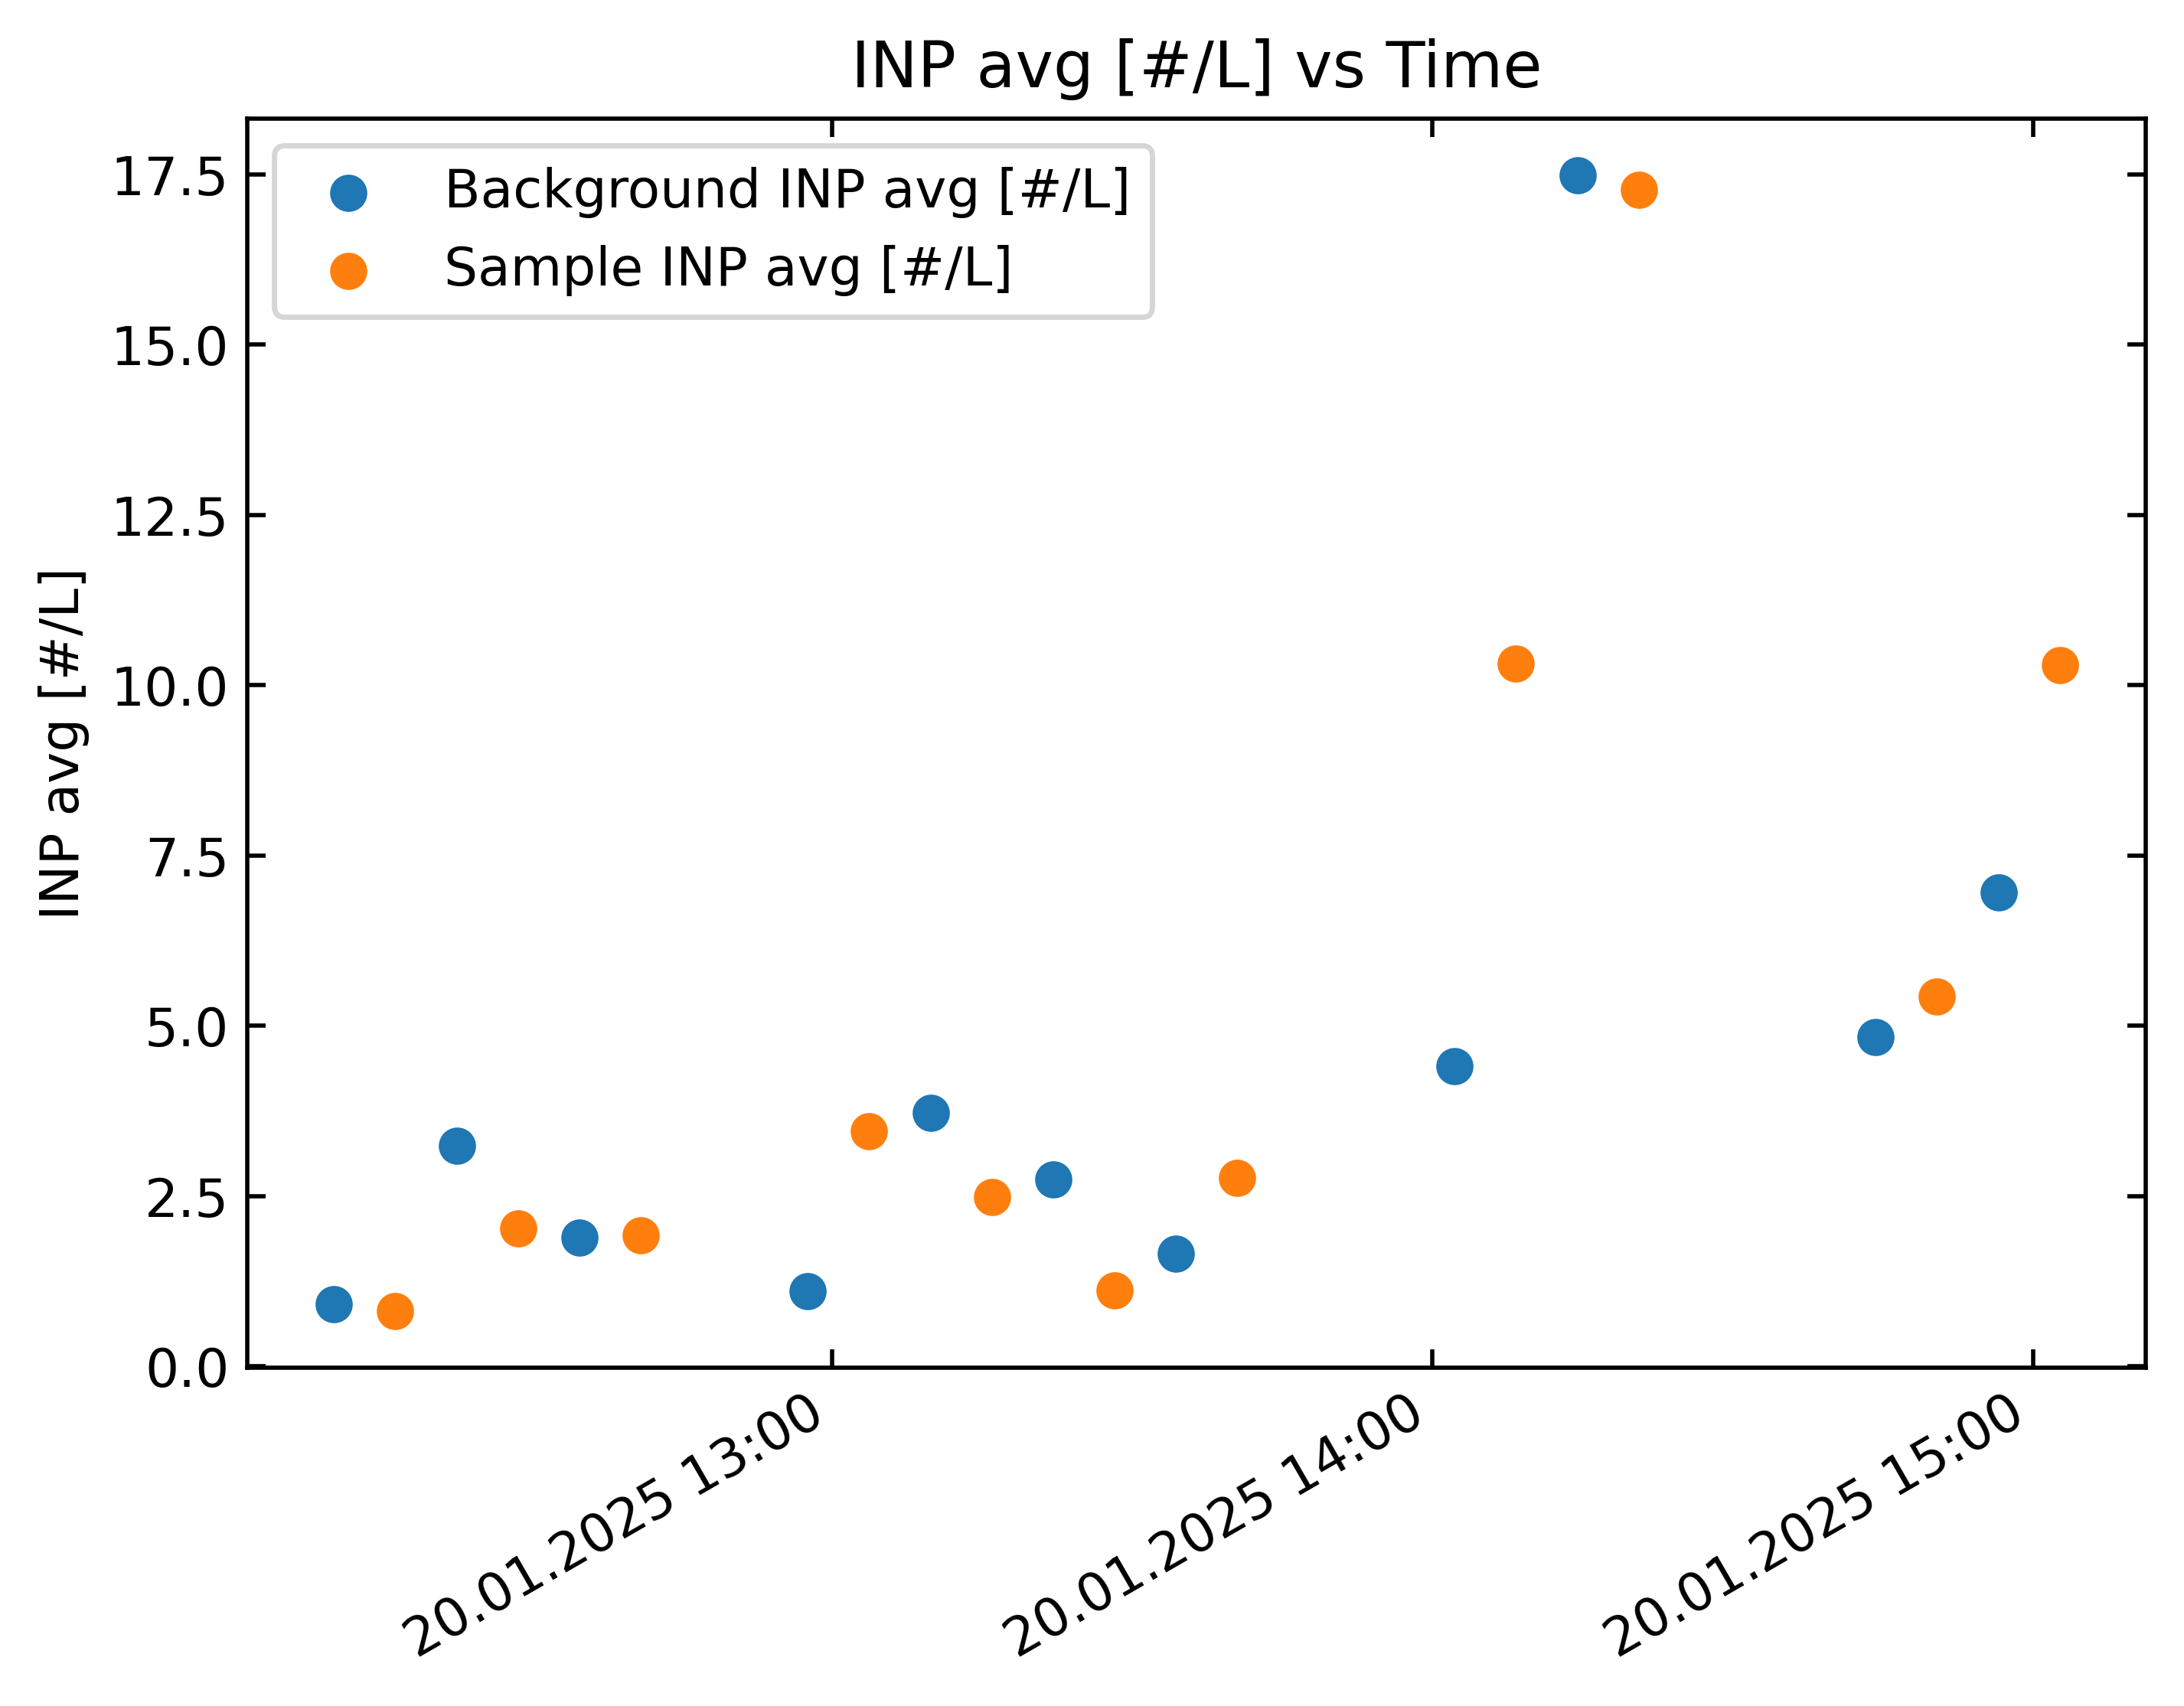

In [1]:
# 整合画出一天INP浓度的散点时间序列
# 并输出-15degC的INP浓度平均值

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

#一天数据集处理
data = pd.read_csv(r"D:\Coding\Data\Lanzhou_cfdc\test\data_20250120T082513.csv")
data = data.dropna(subset=['Lamina Average T [C]'])

#根据文件名确定当天日期
base_date = pd.to_datetime("2025-01-20")

dt = base_date + pd.to_timedelta(data['Time'], unit='s')

x = dt
diff = data['Lamina Average T [C]'] - data['Lamina T Set [C]']
background_toggle = data['Background INP avg [#/L] Toggle']
sample_toggle = data['Sample INP avg [#/L] Toggle']
y1 = data['Background INP avg [#/L]'][background_toggle==True].reindex(x.index, fill_value=np.nan)
y2 = data['Sample INP avg [#/L]'][sample_toggle==True].reindex(x.index, fill_value=np.nan)
y1_last = y1[y1.notna() & y1.shift(-1).isna()].reindex(x.index, fill_value=np.nan)
y2_last = y2[y2.notna() & y2.shift(-1).isna()].reindex(x.index, fill_value=np.nan)

fig = plt.figure(dpi=500)
ax = fig.add_subplot(111)

ax.scatter(x, y1_last, label='Background INP avg [#/L]')
ax.scatter(x, y2_last, label='Sample INP avg [#/L]')

ax.xaxis.set_major_locator(mdates.HourLocator(interval=1)) # 每小时一个主刻度
#ax.xaxis.set_minor_locator(mdates.MinuteLocator(interval=10)) # 每10分钟一个次刻度
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d.%m.%Y %H:%M"))
plt.gcf().autofmt_xdate()# 自动旋转日期标记
ax.set_ylabel('INP avg [#/L]')
ax.tick_params(which='both', top=True, bottom=True, left=True, right=True, direction='in')
ax.set_title('INP avg [#/L] vs Time')
ax.legend()

# 计算并输出-15degC的INP浓度平均值
y1_15 = y1[data['Lamina T Set [C]']==-15.0][y1.notna() & y1.shift(-1).isna()]
print(y1_15)
mean_y1_15 = y1_15.mean()
print(f"Mean Background INP avg [#/L] at -15°C: {mean_y1_15}")

y2_15 = y2[data['Lamina T Set [C]']==-15.0][y2.notna() & y2.shift(-1).isna()]
mean_y2_15 = y2_15.mean()
print(f"Mean Sample INP avg [#/L] at -15°C: {mean_y2_15}")

y_net_15 = mean_y2_15 - mean_y1_15
print(f"Mean Net INP avg [#/L] at -15°C: {y_net_15}")

## 后续计划

单日的数据处理到这里就差不多了, 现在需要考虑:

1. 将单日数据放到较长的时间序列(比如说, 一个月的长度)中观察, 与降水数据相匹配.

    在此之前, 需要确定一件事: 每天各种温度的INP浓度只会测量一次吗?

    回答这个问题有什么用呢? 如果只测量一次, 那么一天只有一个数据点; 如果有多一点的话, 数据的时间分辨率会高一点.

2. 重复的日期如何处理, 如何选择删去哪一个?

3. 为何主刻度和次刻度没有重合? 估计是四舍五入的问题, 如何解决?

In [26]:
y1_last = y1[y1.notna() & y1.shift(-1).isna()]
y2_last = y2[y2.notna() & y2.shift(-1).isna()]
#print(y1_last)
#print(y2_last)

net = y2_last.values - y1_last.values
idx = np.round((y1_last.index + y2_last.index) / 2).astype(int)
print(y1_last.index)
print(y2_last.index)
print(idx)
np.mean(y1_last.index)


Index([13496, 14232, 14968, 16337, 17073, 17809, 18545, 20216, 20952, 22740,
       23476],
      dtype='int64')
Index([13864, 14600, 15336, 16705, 17441, 18177, 18913, 20584, 21320, 23108,
       23844],
      dtype='int64')
Index([13680, 14416, 15152, 16521, 17257, 17993, 18729, 20400, 21136, 22924,
       23660],
      dtype='int64')


np.float64(18167.636363636364)

In [31]:
def extract_segment_last(s):
    """
    输入: 一个 Series 对象, 这个 Series 由'数据--NaN--数据'交替组成.

    返回: Series 对象, 包含每个测量段的最后一个值(认为数据趋于稳定后才有意义), 索引为这些值的原始索引.

    调用此函数前, 需要:
    - import numpy as np
    - import pandas as pd
    """
    ### 保证输入是 Series
    if not isinstance(s, pd.Series):
        raise TypeError("Input must be a pandas Series.")
    
    ### 1. 提取每段非 NaN 区间的尾值
    mask = s.notna() & s.shift(-1).isna()
    s_last = s[mask]

    ### 2. 如果没有尾值，返回空 Series
    if len(s_last) == 0:
        return pd.Series(dtype=float)
    
    return s_last


def compute_net(sam, bac):
    """
    输入: 两个 Series 对象(索引为整数), 计算净值 (Sample - Background), 如果净值小于 0, 则取 0.

    返回: Series 对象, 索引为两个输入 Series 索引的平均值.

    调用此函数前, 需要:
    - import numpy as np
    - import pandas as pd
    - 定义 extract_segment_last 函数, 用于获取每个测量段的最后一个值
    """

    sam = extract_segment_last(sam)
    bac = extract_segment_last(bac)

    ### 保证两个 Series 长度相同
    if len(sam) != len(bac):
        raise ValueError("Sample and background have different number of measurement segments.")

    idx = np.round((bac.index + sam.index)/2).astype(int)
    net = sam.values - bac.values
    net[net < 0] = 0
    return pd.Series(net, index=idx) 

In [32]:
sam = pd.Series(dtype=float)
bac = pd.Series(dtype=float)
compute_net(sam, bac)

Series([], dtype: float64)

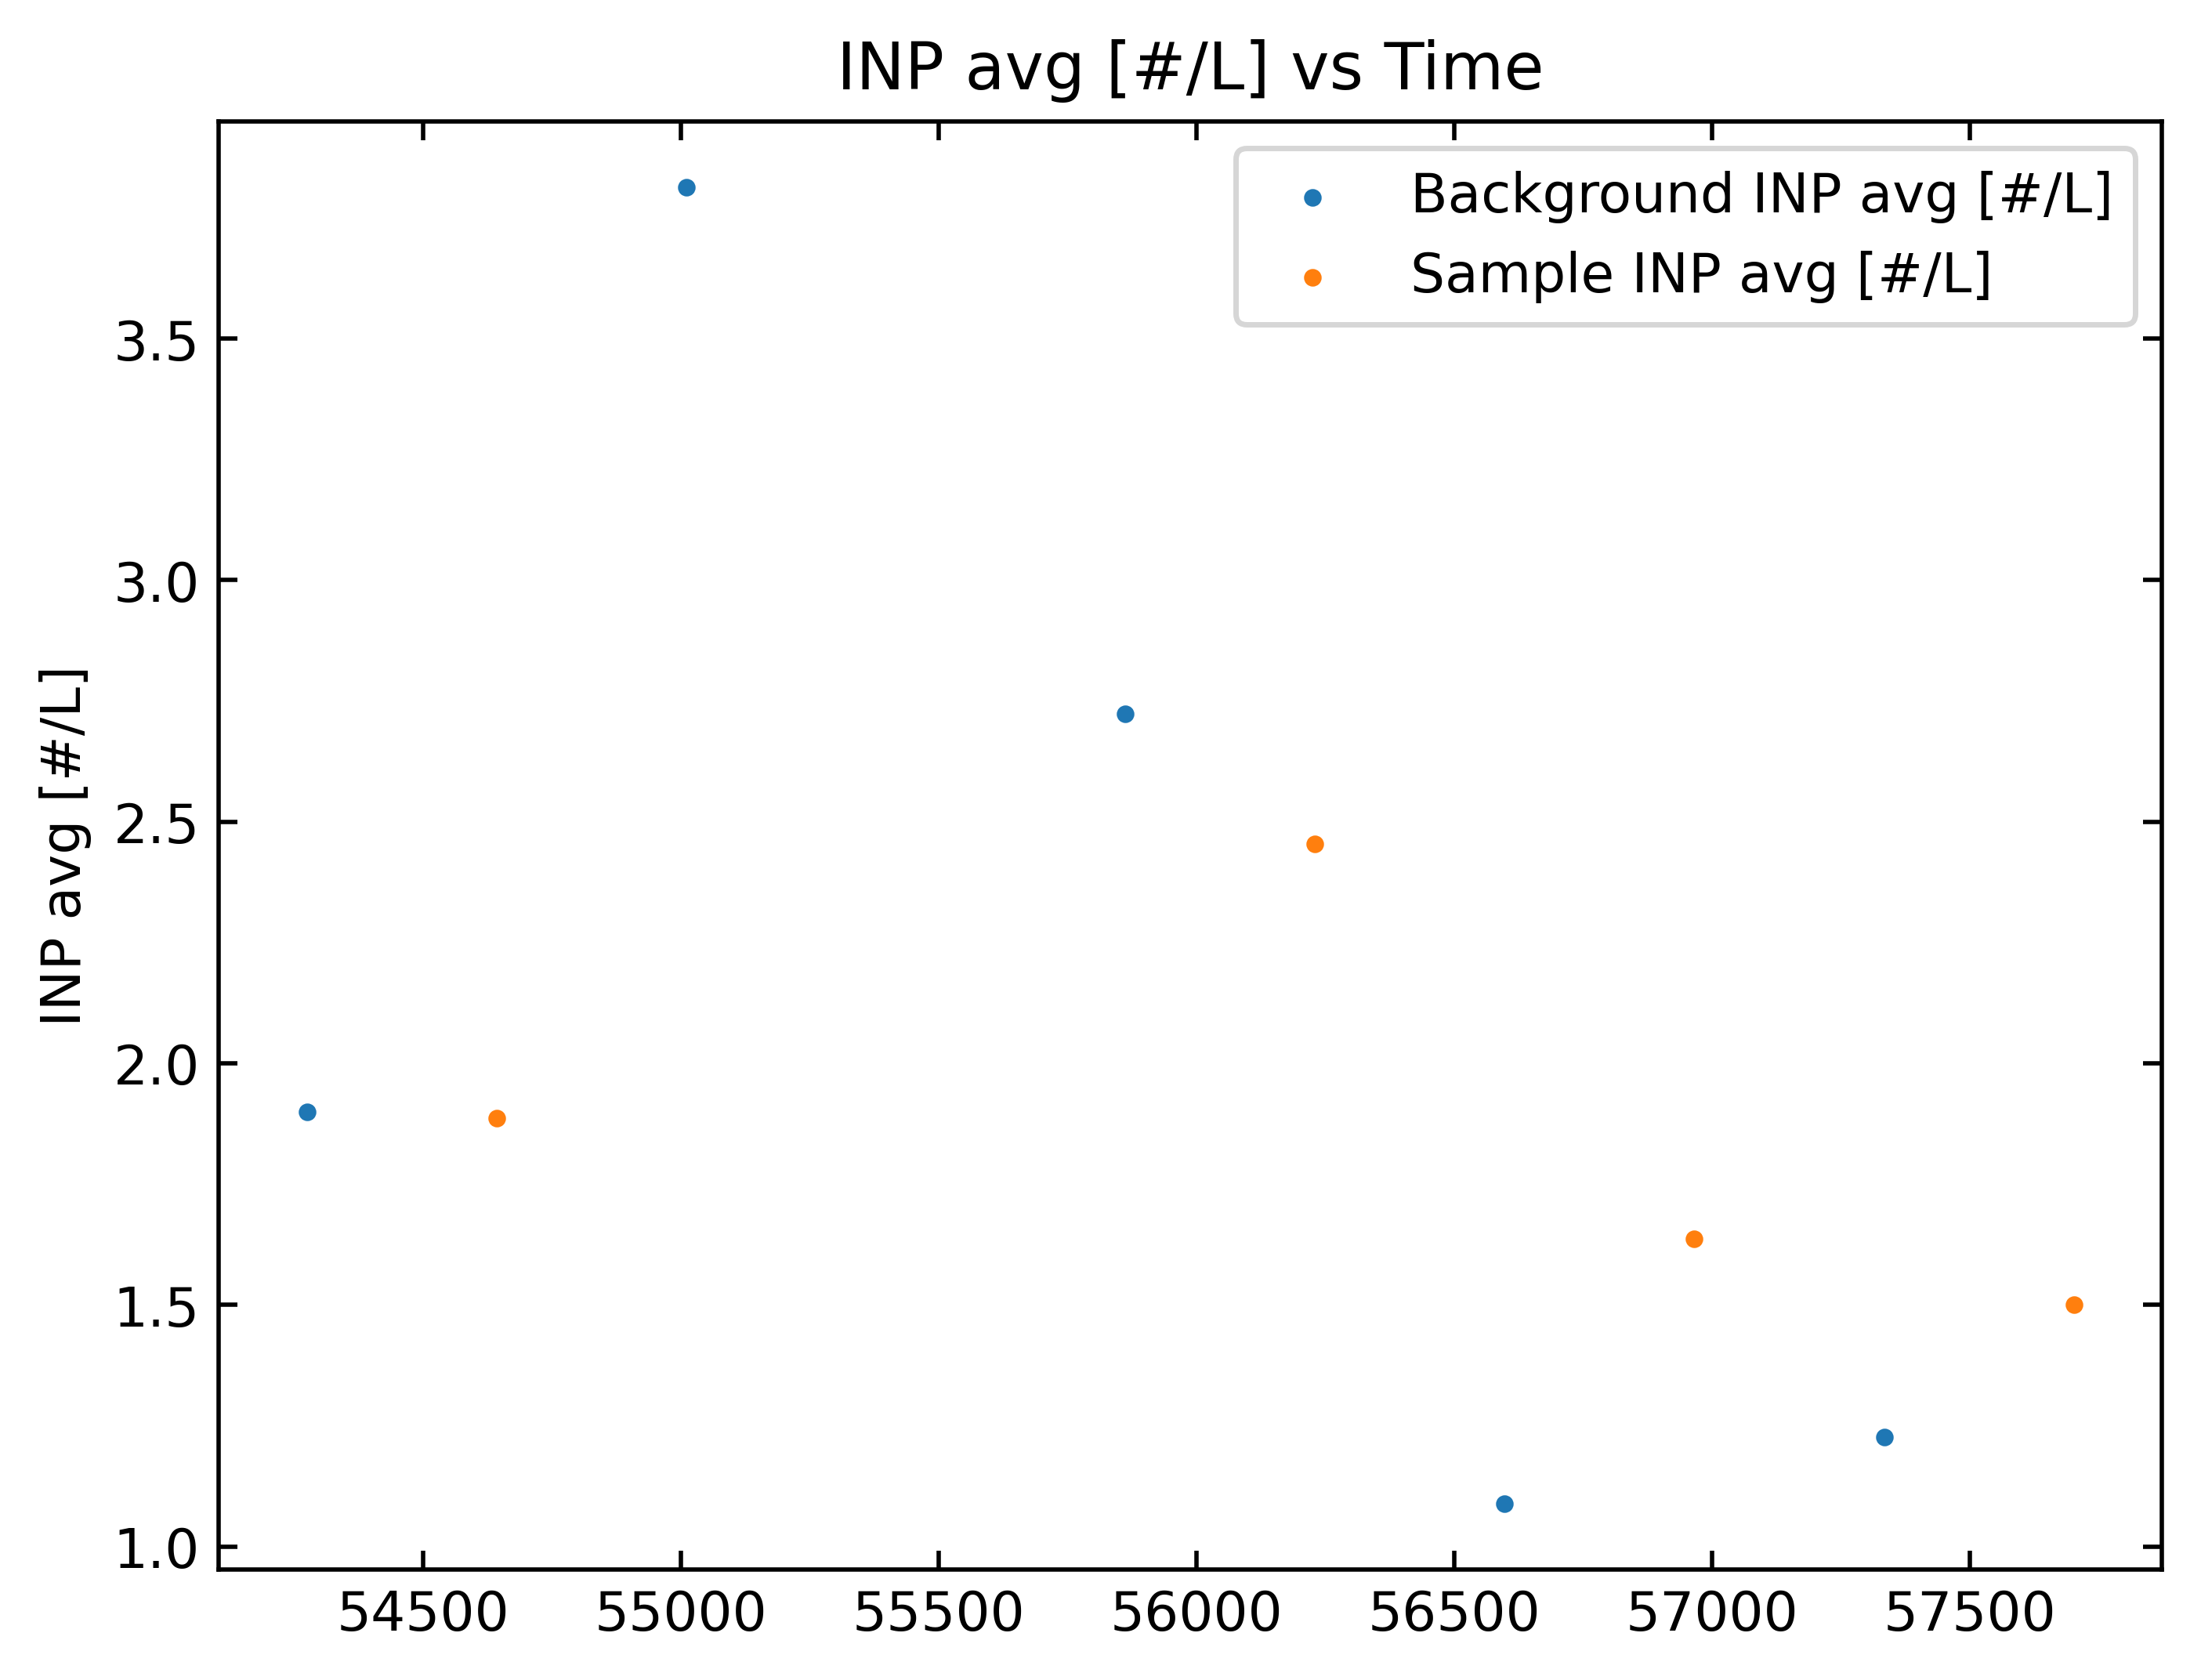

In [45]:
# 整合画出一天INP浓度的时间序列

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

#一天数据集处理
data = pd.read_csv(r"D:\Coding\Data\Lanzhou_cfdc\data_20250101T101850.csv")
data = data.dropna(subset=['Lamina Average T [C]'])

#根据文件名确定当天日期
base_date = pd.to_datetime("2025-01-01")
dt = base_date + pd.to_timedelta(data['Time'], unit='s')

#x = dt
x = data['Time']
diff = data['Lamina Average T [C]'] - data['Lamina T Set [C]']
background_toggle = data['Background INP avg [#/L] Toggle']
sample_toggle = data['Sample INP avg [#/L] Toggle']
y1 = data['Background INP avg [#/L]'][background_toggle==True][data['Lamina T Set [C]']==-15.0].reindex(x.index, fill_value=np.nan)
y2 = data['Sample INP avg [#/L]'][sample_toggle==True][data['Lamina T Set [C]']==-15.0].reindex(x.index, fill_value=np.nan)

y1_last = y1[y1.notna() & y1.shift(-1).isna()].reindex(x.index, fill_value=np.nan)
y2_last = y2[y2.notna() & y2.shift(-1).isna()].reindex(x.index, fill_value=np.nan)
fig = plt.figure(dpi=500)
ax = fig.add_subplot(111)

ax.scatter(x, y1_last, label='Background INP avg [#/L]', s=5)
ax.scatter(x, y2_last, label='Sample INP avg [#/L]', s=5)
#ax.plot(x, data['Lamina T Set [C]'], label='Lamina Average T [C]', color='green', alpha=0.5)

#ax.xaxis.set_major_locator(mdates.HourLocator(interval=1)) # 每小时一个主刻度
#ax.xaxis.set_minor_locator(mdates.MinuteLocator(interval=10)) # 每10分钟一个次刻度
#ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y.%m.%d %H:%M"))
#plt.gcf().autofmt_xdate()# 自动旋转日期标记
ax.set_ylabel('INP avg [#/L]')
ax.tick_params(which='both', top=True, bottom=True, left=True, right=True, direction='in')
ax.set_title('INP avg [#/L] vs Time')
ax.legend()


In [70]:
def merge_series_with_tag(sam, bac, tag1='Sample', tag2='Background'):
    # 分别为两个 Series 创建标签
    df1 = pd.DataFrame({'value': sam, 'tag': tag1})
    df2 = pd.DataFrame({'value': bac, 'tag': tag2})

    # 纵向合并 + 按索引排序
    df = pd.concat([df1, df2]).sort_index()

    return df

In [71]:
back = pd.Series([10, 11, 12, 13], index=[1, 3, 5, 7])
samp = pd.Series([20, 21, 22], index=[2, 4, 6])


df = merge_series_with_tag(samp, back)
print(df)

   value         tag
1     10  Background
2     20      Sample
3     11  Background
4     21      Sample
5     12  Background
6     22      Sample
7     13  Background


In [72]:
df = df.drop(df[df['tag'] == df['tag'].shift(-1)].index)
df

,value,tag
1,10,Background
2,20,Sample
3,11,Background
4,21,Sample
5,12,Background
6,22,Sample
7,13,Background


In [73]:
samp = df[df['tag'] == 'Sample']['value']
back = df[df['tag'] == 'Background']['value']

In [76]:
print(samp)
print(back)

2    20
4    21
6    22
Name: value, dtype: int64
1    10
3    11
5    12
Name: value, dtype: int64


In [75]:
back = back[:-1]
print(back)

1    10
3    11
5    12
Name: value, dtype: int64
